# Power System Expansion Under Uncertainty — Peru

**Tornado and P10–P90 analysis of a system-dynamics expansion model, 2025–2050.**

This notebook is the executable record of the Peru experiment. It

1. states what the model is and how a factor is made to reach it,
2. builds the design — 1 base run, 2 tornado runs per factor, 120 Monte Carlo samples,
3. runs, or loads, the ensemble through Vensim DSS,
4. draws the **tornado diagram**,
5. draws the **P10–P90 envelopes** of the four KPIs,
6. selects the **best and worst case** on one stated metric and draws, for those two and
   the base case, **electricity generation by technology** and **installed capacity by
   technology**,
7. reports the method checks — sampling design, convergence, rank correlation — and the
   tables the paper needs.

The question is not *what will happen in Peru* but **which unknowns actually move the
system**. Four drivers are in play: a **fuel price** change, a change in **demand growth**,
and **delays in project entry** on the generation and on the transmission side.

> `README.md` documents the pipeline, the failure modes, the figure conventions and the
> limitations. This notebook assumes it has been read.

## 0. Setup

All the machinery lives in `peru_tornado.py`: the model patching, the design, the Vensim
DSS driver, the post-processing and the figures. The notebook orchestrates it and explains
each step. Keeping the driver in a module is what lets the sweep run as six parallel
processes — a notebook kernel cannot hold six independent Vensim engines.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, display

# The notebook lives in notebooks/; everything else is addressed from the repository root.
ROOT = Path.cwd() if (Path.cwd() / "peru_tornado.py").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

import peru_tornado as pt

RESULTS = ROOT / "results" / "peru"
RUNS, FIGURES = RESULTS / "runs", RESULTS / "figures"

# Which factor set is in play depends on which published model exists. The 4-factor
# design needs ModeloCh4_Sens2.vpmx, which has to be published by hand from Vensim DSS
# (README section 6); until then the notebook runs the three original factors.
WITH_DEMAND = pt.VENSIM_MODEL_4F.exists()
pt.VENSIM_MODEL = pt.VENSIM_MODEL_4F if WITH_DEMAND else pt.VENSIM_MODEL_3F
pt.select_factors(WITH_DEMAND)

print(f"Model in use : {pt.VENSIM_MODEL.name}  ({'4' if WITH_DEMAND else '3'} factors)")
for key, (knob, half, label) in pt.FACTORS.items():
    print(f"  {label:32s} {knob:18s} +/-{half:.0%}")
if not WITH_DEMAND:
    print("\nNOTE: the demand factor is not in this run. Publish "
          "model/ModeloCh4_Sens2.vpmx from Vensim DSS to include it; see README section 6.")

Model in use : ModeloCh4_Sens2.vpmx  (4 factors)
  Generation project delays        Sens Gen Delay     +/-20%
  Transmission project delays      Sens Trans Delay   +/-20%
  Fuel prices                      Sens Fuel Price    +/-15%
  Demand growth                    Sens Demand        +/-20%


## 1. The model, and how a factor reaches it

A system-dynamics expansion module coupled to a congestion-aware dispatch module, solved
over **300 months (25 years)** from January 2025 at a time step of 0.25 months. Peru is
represented by 6 zones and 14 generation technologies per zone.

The one thing to understand before changing anything: **a published Vensim model does not
read its workbook at run time.** `GET XLS CONSTANTS` and `GET XLS DATA` are resolved when
the model is *published*, and their values are baked into the `.vpmx`. The Vensim DLL, in
turn, loads published models only — it cannot execute a `.mdl`. So rewriting `PERU.xlsx`
beside the published model changes nothing, and it does so **silently**: the sweep runs
happily and returns the same numbers for every sample.

The factors are therefore driven through **named constants and `SIMULATE>SETVAL`**. The
cell below prints the patch that creates them: each uncertain input is multiplied by a
sensitivity constant whose default value, zero, reproduces the original model exactly.

In [2]:
import inspect

# The model patch, in full: this is what turns four spreadsheet inputs into four knobs
# the simulation engine can be told to move.
print(inspect.getsource(pt.add_knobs))

def add_knobs(txt):
    """Adds the three sensitivity constants to the .mdl text (base value 0 = original model)."""
    extras = []
    # Fuel prices
    txt, e = _replace_equation(txt, "Fuel Cost[ZTech]",
                               f"Fuel Cost Data[ZTech]*(1+{KNOB_FUEL})", keep_as="Fuel Cost Data[ZTech]")
    extras.append(e)
    # Generation delays: same mechanism used in PERU.xlsx ("Other delays" = f x (construction + licensing))
    txt, _ = _replace_equation(txt, "Other Generation delays[ZTech]",
                               f"{KNOB_GEN}*(Construction time by tech[ZTech]+Generation License Delay[ZTech])")
    # Transmission delays: every project stage is scaled by (1+f)
    for lhs in ["Public Tender Delay TI", "Investor Selection Delay TI[TrasmTech]",
                "Transmission License Delay TI[TrasmTech]", "Transmission Construction Delay TI[TrasmTech]",
                "Public Tender Delay TG", "Investor Selection Delay TG",
                "Transmission License Delay

In [3]:
# The base configuration the experiment perturbs, read from the workbook itself.
import openpyxl

book = openpyxl.load_workbook(pt.DATA_XLSX, read_only=True, data_only=True)
base_sheet = book["Base"]
initial_mw = sum(v for v in (base_sheet.cell(row=5, column=c).value for c in range(3, 87))
                 if isinstance(v, (int, float)))
gen_delay_base = book["Gen Investment parameters"]["B15"].value
params = book["General Parameters"]
switches = {
    "Grid-enhancing technologies (B22)": params["B22"].value,
    "System-level battery storage (B23)": params["B23"].value,
    "Dispatch path, 0 = internal Vensim (B24)": params["B24"].value,
    "Planned generation, 1 = exogenous plan (B12)": params["B12"].value,
    "DER expansion endogenous (B14)": params["B14"].value,
}
book.close()

print(f"Initial installed capacity (Base!C5:CH5)      {initial_mw:>12,.0f} MW")
print(f"'Other delays' fraction, base case (B15)      {gen_delay_base:>12.2f}")
print("   The generation-delay knob replaces that input, so the knob is")
print("   (1 + B15)*(1 + change) - 1: base -0.20, at -20 % -> -0.36, at +20 % -> -0.04.\n")
for name, value in switches.items():
    print(f"   {name:48s} {value}")

Initial installed capacity (Base!C5:CH5)            14,057 MW
'Other delays' fraction, base case (B15)             -0.20
   The generation-delay knob replaces that input, so the knob is
   (1 + B15)*(1 + change) - 1: base -0.20, at -20 % -> -0.36, at +20 % -> -0.04.

   Grid-enhancing technologies (B22)                0
   System-level battery storage (B23)               0
   Dispatch path, 0 = internal Vensim (B24)         0
   Planned generation, 1 = exogenous plan (B12)     1
   DER expansion endogenous (B14)                   1


## 2. The design

Three groups of runs, each answering a different question:

* the **base case** fixes the reference every other run is compared against;
* the **tornado runs** move one factor at a time to each end of its range, which is what
  makes a tornado bar attributable to that factor;
* the **Monte Carlo runs** move every factor at once, which is what the P10–P90 band and
  the rank correlations need.

The Monte Carlo sample is a Latin hypercube: each factor's range is cut into as many equal
intervals as there are samples, one value is drawn at random inside each, and the intervals
are paired at random across factors. That covers every range evenly with far fewer runs
than simple random sampling.

The sample is declared as a list of **blocks** (`MC_BLOCKS`) rather than a flat sample
count — currently one block of 120 with seed 2026. Each block is a proper Latin hypercube
and the union of several keeps uniform marginals, so a smaller design stays an exact prefix
of a larger one: appending `(80, 2027)` would extend the study to 200 samples without
invalidating a single completed run. The seeds and the factor order are fixed in the source,
so the design is reproducible from the repository alone.

In [4]:
design = pt.design_runs()
RESULTS.mkdir(parents=True, exist_ok=True)
design.to_csv(RESULTS / "experiment_design.csv")

print(f"{len(design)} runs: " + ", ".join(
    f"{int(n)} {k}" for k, n in design.kind.value_counts().items()))
print("Monte Carlo blocks: " + ", ".join(f"{n} samples, seed {s}" for n, s in pt.MC_BLOCKS))
display(design.head(1 + 2 * len(pt.FACTORS)))

129 runs: 120 montecarlo, 8 tornado, 1 base
Monte Carlo blocks: 120 samples, seed 2026


,kind,gen_delay,trans_delay,fuel,demand
run_id,,,,,
base,base,0.0,0.0,0.00,0.0
oat_gen_delay_low,tornado,-0.2,0.0,0.00,0.0
oat_gen_delay_high,tornado,0.2,0.0,0.00,0.0
oat_trans_delay_low,tornado,0.0,-0.2,0.00,0.0
oat_trans_delay_high,tornado,0.0,0.2,0.00,0.0
oat_fuel_low,tornado,0.0,0.0,-0.15,0.0
oat_fuel_high,tornado,0.0,0.0,0.15,0.0
oat_demand_low,tornado,0.0,0.0,0.00,-0.2
oat_demand_high,tornado,0.0,0.0,0.00,0.2


### Design diagnostics

Two properties have to hold for the Monte Carlo half of the study to mean anything.

**Stratum coverage.** A Latin hypercube places exactly one sample in each of the *n* equal
intervals of every factor. The design file rounds each sampled value to four decimals — so
that a run can be matched to its design row by exact comparison — and a value drawn very
close to a stratum boundary can round across it, which is why the count below is reported
rather than asserted. It is checked per block, since that is the level at which the
property is defined. A count one or two short of *n* is rounding; a count far short would
mean the sampler is wrong.

**Near-orthogonality.** A rank correlation between a factor and a KPI is only attributable
when the factors are close to uncorrelated; a strong correlation between two of them would
let one absorb the other's effect. The realised value is reported rather than assumed.

In [5]:
mc = design[design.kind == "montecarlo"][list(pt.FACTORS)].astype(float)

start = 0
for size, seed in pt.MC_BLOCKS:
    block = mc.iloc[start:start + size]
    unit = pd.DataFrame({k: (block[k] + pt.FACTORS[k][1]) / (2 * pt.FACTORS[k][1])
                         for k in pt.FACTORS})
    strata = {k: len(np.unique(np.minimum((v * size).astype(int), size - 1)))
              for k, v in unit.items()}
    worst = min(strata.values())
    print(f"block of {size} (seed {seed}): {worst}/{size} strata occupied in the "
          f"least-covered factor ({min(strata, key=strata.get)})")
    start += size

corr = mc.corr().to_numpy()
np.fill_diagonal(corr, 0.0)
off = np.abs(corr[np.triu_indices_from(corr, 1)])
print(f"\nover all {len(mc)} samples: max |correlation| between factors {off.max():.4f}, "
      f"mean {off.mean():.4f}")
display(mc.describe().T[["min", "mean", "max"]])

block of 120 (seed 2026): 117/120 strata occupied in the least-covered factor (fuel)

over all 120 samples: max |correlation| between factors 0.1810, mean 0.0756


,min,mean,max
gen_delay,-0.1998,-0.000002,0.1999
trans_delay,-0.1992,0.000018,0.1973
fuel,-0.1489,0.000078,0.1484
demand,-0.1990,0.000229,0.1999


## 3. Running the ensemble

A 300-month run takes about 5.5 minutes under Vensim, so the driver runs several at once:
each worker simulates in its own temporary folder with its own copy of the model, and
worker processes are recycled every four runs because Vensim keeps every simulated run in
memory. With six workers the full design takes roughly three to four hours on an 8-core
machine.

The sweep is **resumable, and strict about it**: every run writes its results next to the
factor values it used, and a cached run is reused only if those values match the design
*exactly*. An interrupted sweep therefore costs only the runs in flight, and a change to
the design correctly invalidates the runs it affects rather than silently mixing two
experiments.

The cell below is guarded: it reports what is on disk and prints the command for whatever
is missing, rather than launching a three-hour job from inside a notebook.

In [6]:
done = {p.stem for p in RUNS.glob("*.json")} if RUNS.exists() else set()
pending = [rid for rid in design.index if rid not in done]
print(f"{len(design) - len(pending)} of {len(design)} runs already on disk, {len(pending)} pending")

if pending:
    print("\nLaunch the sweep from the repository root:\n")
    print("    python peru_tornado.py --workers 6 --engine vensim\n")
    print("It prints a per-run ETA and can be interrupted and relaunched at will.")
else:
    print("\nNothing left to simulate.")

129 of 129 runs already on disk, 0 pending

Nothing left to simulate.


In [7]:
# Load every completed run that matches the design, and reduce each to its KPIs.
data = {rid: pt.derive(pt.load_run(RUNS / f"{rid}.csv")) for rid in design.index
        if pt._matches_design(RUNS, rid, pt._params(design.loc[rid]))}
kpi = pd.DataFrame({rid: pt.kpis(d) for rid, d in data.items()}).T
print(f"{len(data)} of {len(design)} runs available for analysis")

if "base" not in data:
    raise RuntimeError("the base run is missing; simulate it before going on")

base = kpi.loc["base"]
summary = pd.DataFrame({
    "unit": [u for _, u in pt.KPIS.values()],
    "base case 2050": [base[k] for k in pt.KPIS],
}, index=[label for label, _ in pt.KPIS.values()])
display(summary.style.format({"base case 2050": "{:,.2f}"}))

# A base case that reproduces the published reference is the cheapest possible check that
# the whole chain - patched model, published .vpmx, knobs at their base values - is intact.
print("\nreference base case: 63.85 GW generation, 46,341 km transmission")

129 of 129 runs available for analysis


,unit,base case 2050
Total transmission,km,"46,341.23"
Total transmission capacity,GW,4.56
Total installed generation capacity,GW,63.85
Country average electricity price,USD/MWh,124.46



reference base case: 63.85 GW generation, 46,341 km transmission


### Did the factors actually reach the model?

The failure mode this pipeline is built to avoid raises no error: if the knobs were not
reaching the simulation, every run would return the same numbers and the tornado would be
a row of zeros. The check is one line, and it is worth keeping.

In [8]:
spread = (kpi.std() / kpi.mean().abs()).sort_values(ascending=False)
print("relative spread of each KPI across the available runs:")
print(spread.to_string(float_format="%.4f"))
assert (spread.abs() > 1e-6).all(), \
    "a KPI is constant across the design - the knobs are not reaching the model"
print("\nevery KPI varies across the design: the factors are reaching the model")

relative spread of each KPI across the available runs:
gen_gw     0.1672
trans_km   0.1295
trans_gw   0.0859
price      0.0407

every KPI varies across the design: the factors are reaching the model


## 4. Post-processing: every figure and table

`pt.analyse` does the whole post-processing in one call — tornado, percentile envelopes,
best/worst selection, the per-technology charts, the method checks and the summary
workbook — because the paper needs all of them regenerated together whenever a run is
added. The cells after it display each figure and say what to read in it.

In [9]:
pt._style()
pt.analyse(design, RUNS, FIGURES)
print()
for path in sorted(FIGURES.glob("*")):
    print(f"  {path.name:46s} {path.stat().st_size / 1024:8,.0f} kB")

Post-processing ...


  129 of 129 runs available
  best = mc_009, worst = mc_058


  saved 01_distribution_P10_P90_timeseries.png


  saved 02_distribution_P10_P90_histograms.png


  saved 03_tornado.png


...

  saved 08_transmission_km.png


  saved 09_sampling_design.png


  saved 10_convergence.png


  saved 11_factor_influence.png
  saved tornado_summary.xlsx


  saved 00_summary_table.png

  00_summary_table.png                                187 kB
  01_distribution_P10_P90_timeseries.png              340 kB
  02_distribution_P10_P90_histograms.png              189 kB
  03_tornado.png                                      292 kB
  04_price_best_worst.png                             286 kB
  05_installed_capacity_by_technology.png             301 kB
  06_generation_by_technology.png                     289 kB
  07_transmission_capacity_GW.png                      95 kB
  08_transmission_km.png                              238 kB
  09_sampling_design.png                              311 kB
  10_convergence.png                                  228 kB
  11_factor_influence.png                             293 kB
  tornado_summary.xlsx                                 24 kB


## 5. The tornado diagram

For each KPI, the left and right bar are the change from the base case when one factor
sits at its minimum and at its maximum, with every other factor held at its base value.
Factors are ordered by swing, |max − min|.

One factor moves at a time, which is exactly what makes a bar attributable to that factor —
and also the limitation of the form: it says nothing about interactions. The rank
correlations in section 8 are the complement, measured with all factors moving at once.

A bar is only as meaningful as the range behind it, so the range is printed next to each
factor name.

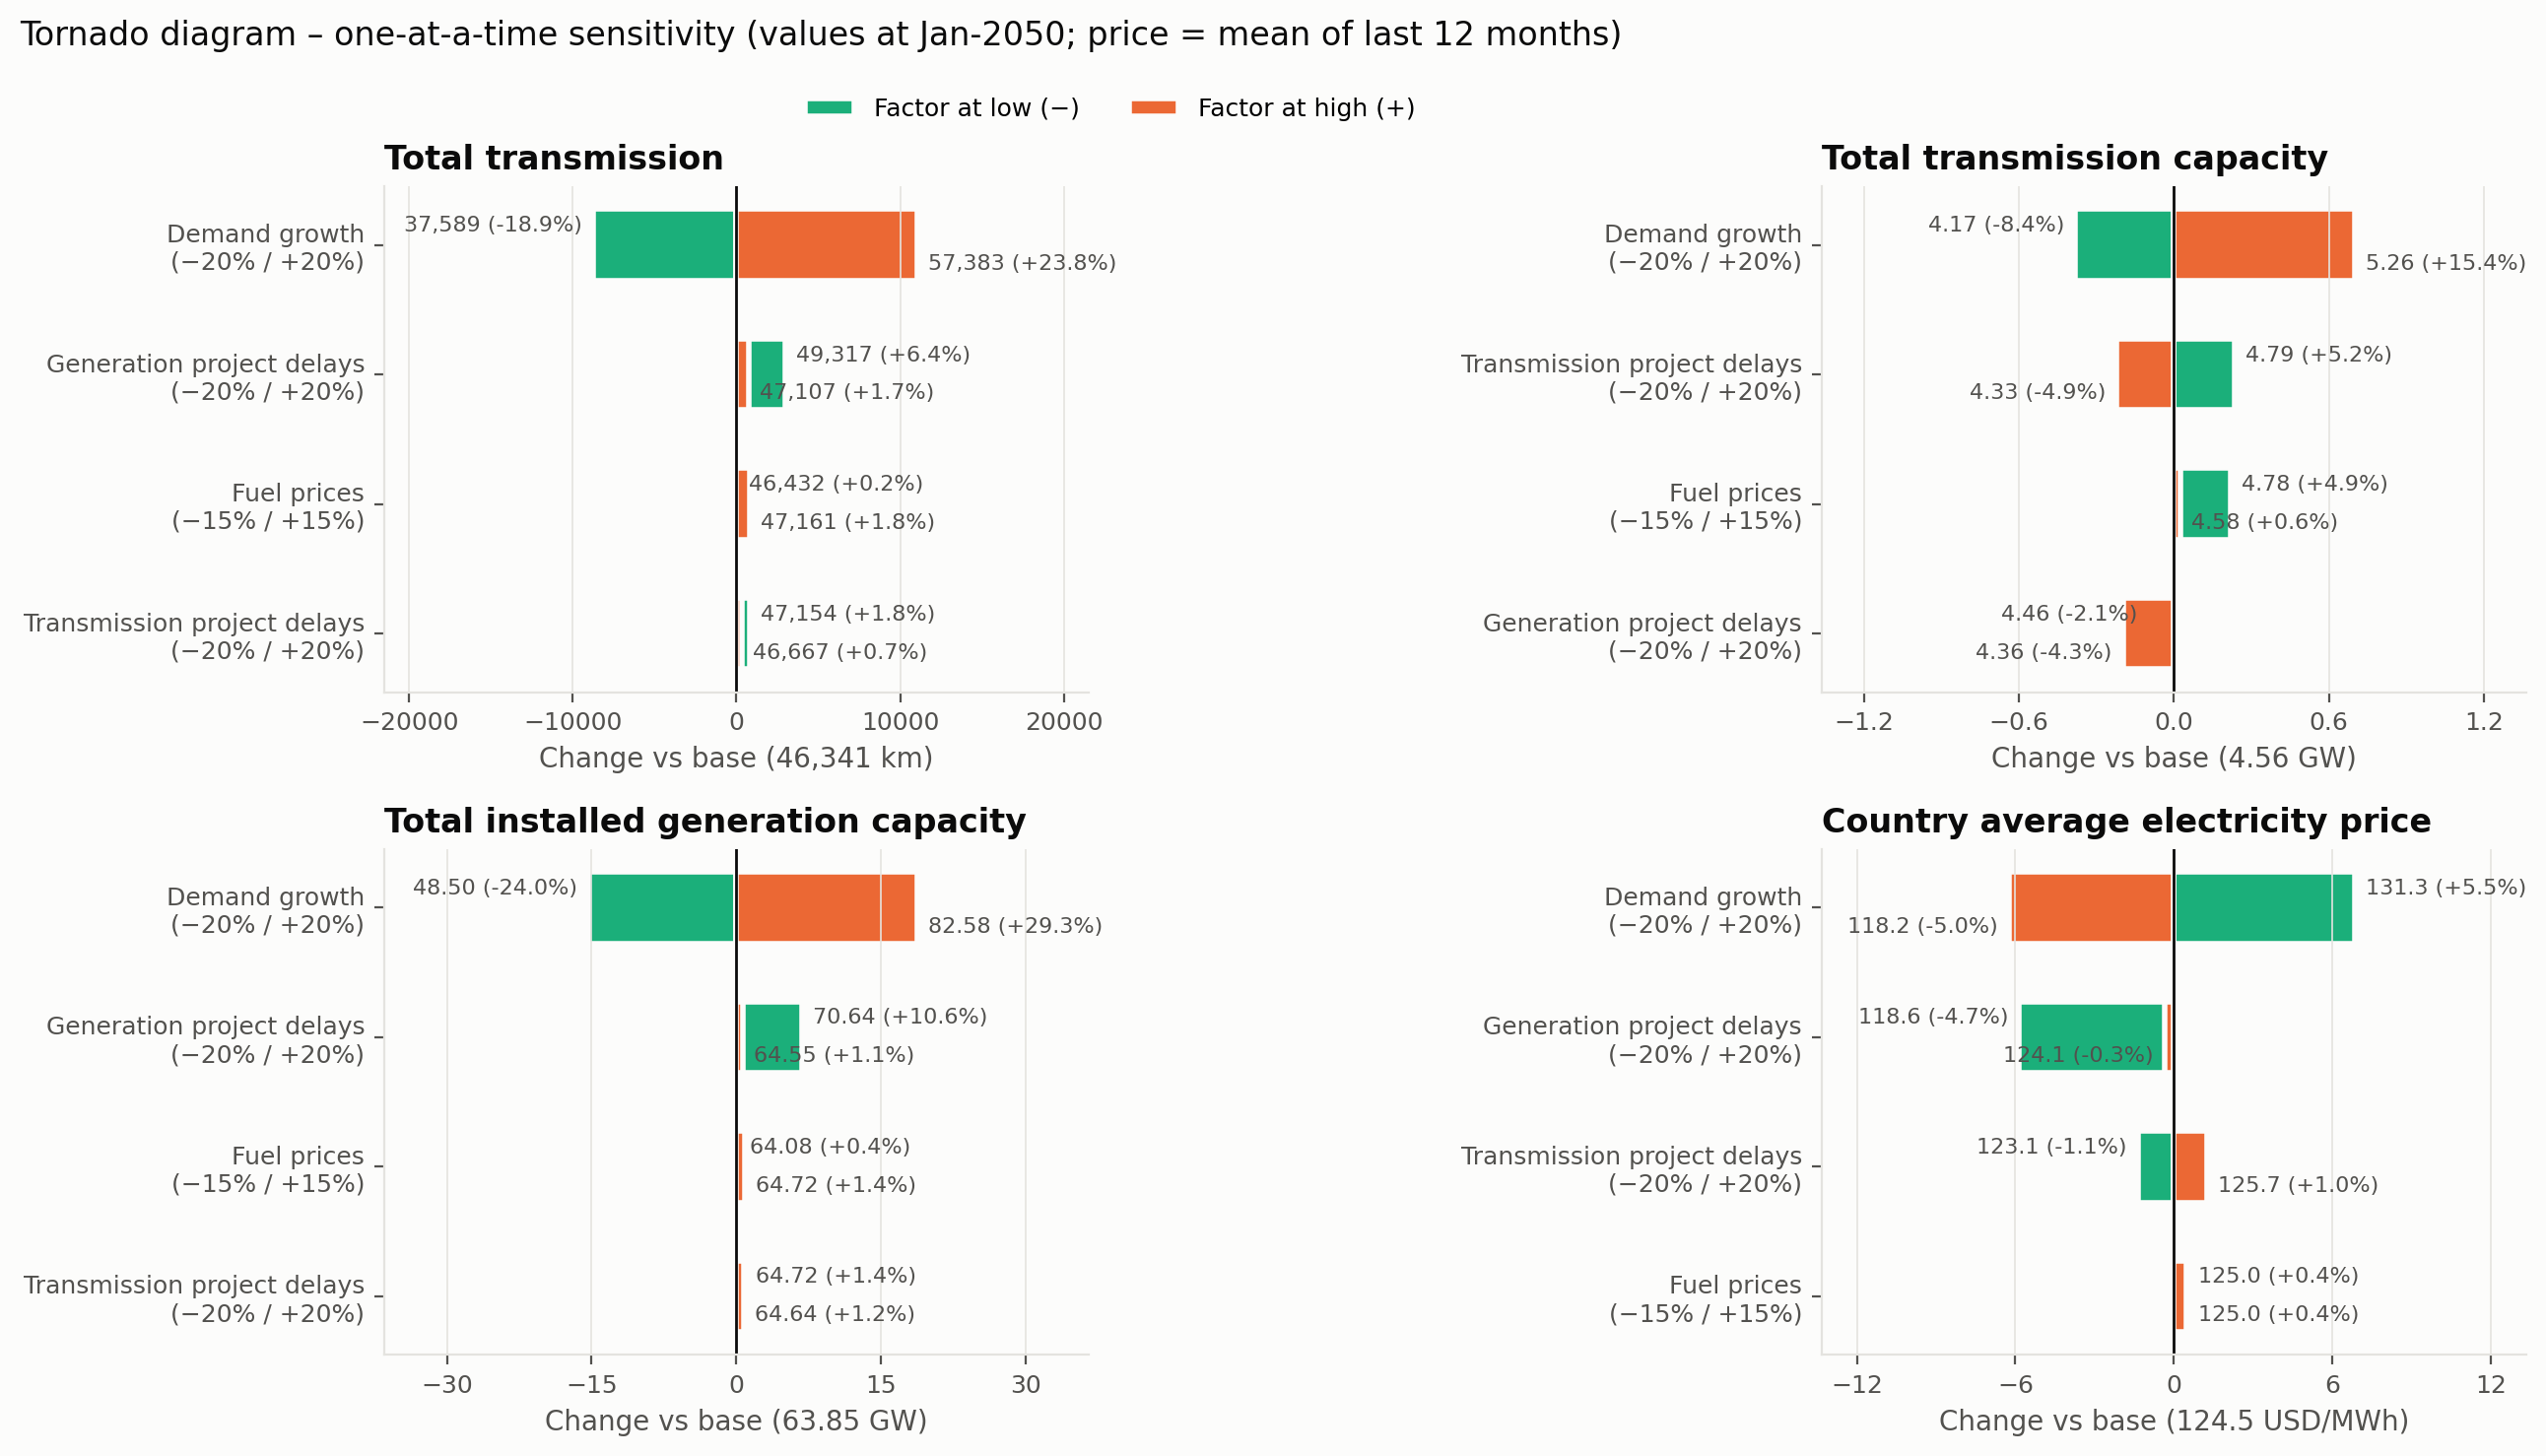

In [10]:
display(Image(filename=str(FIGURES / "03_tornado.png")))

## 6. How wide the future is — P10–P90

From the Monte Carlo runs: at each month, P10 is the value 10 % of the runs fall below,
P50 the median, P90 the value 90 % fall below. The band holds the central 80 % of
outcomes. The first figure shows it over time, the second the distribution of each KPI in
2050.

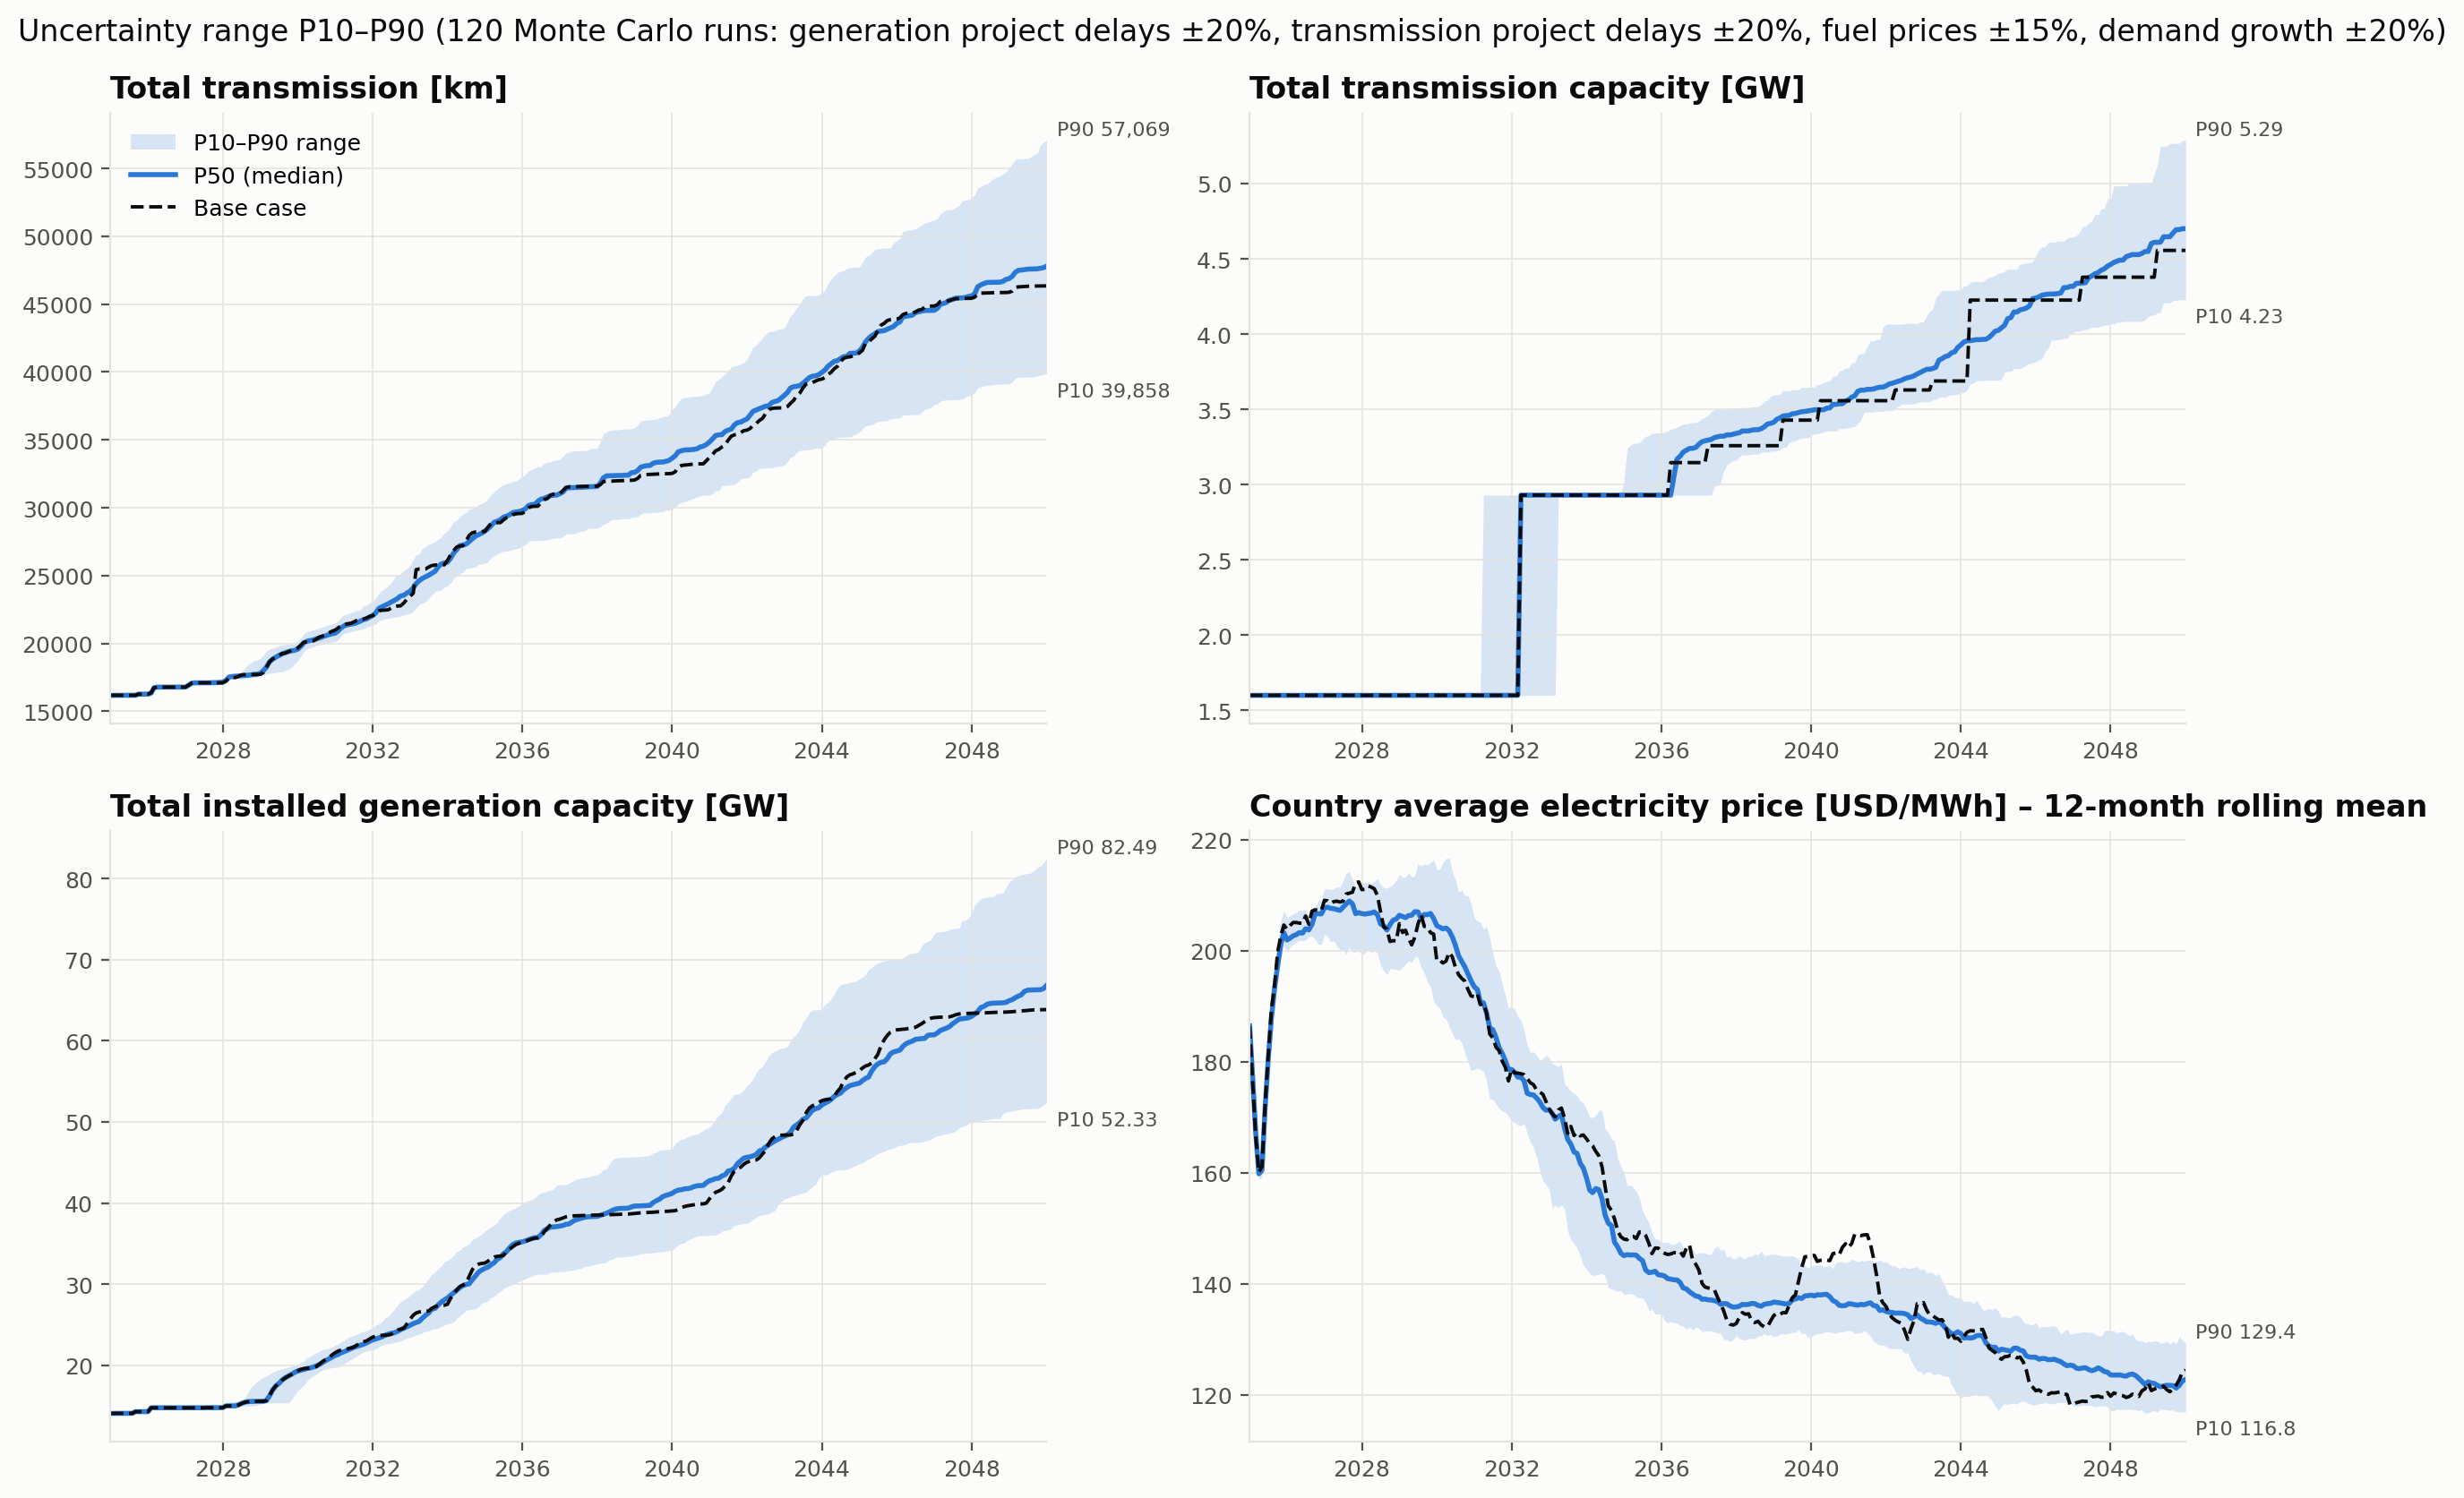

In [11]:
display(Image(filename=str(FIGURES / "01_distribution_P10_P90_timeseries.png")))

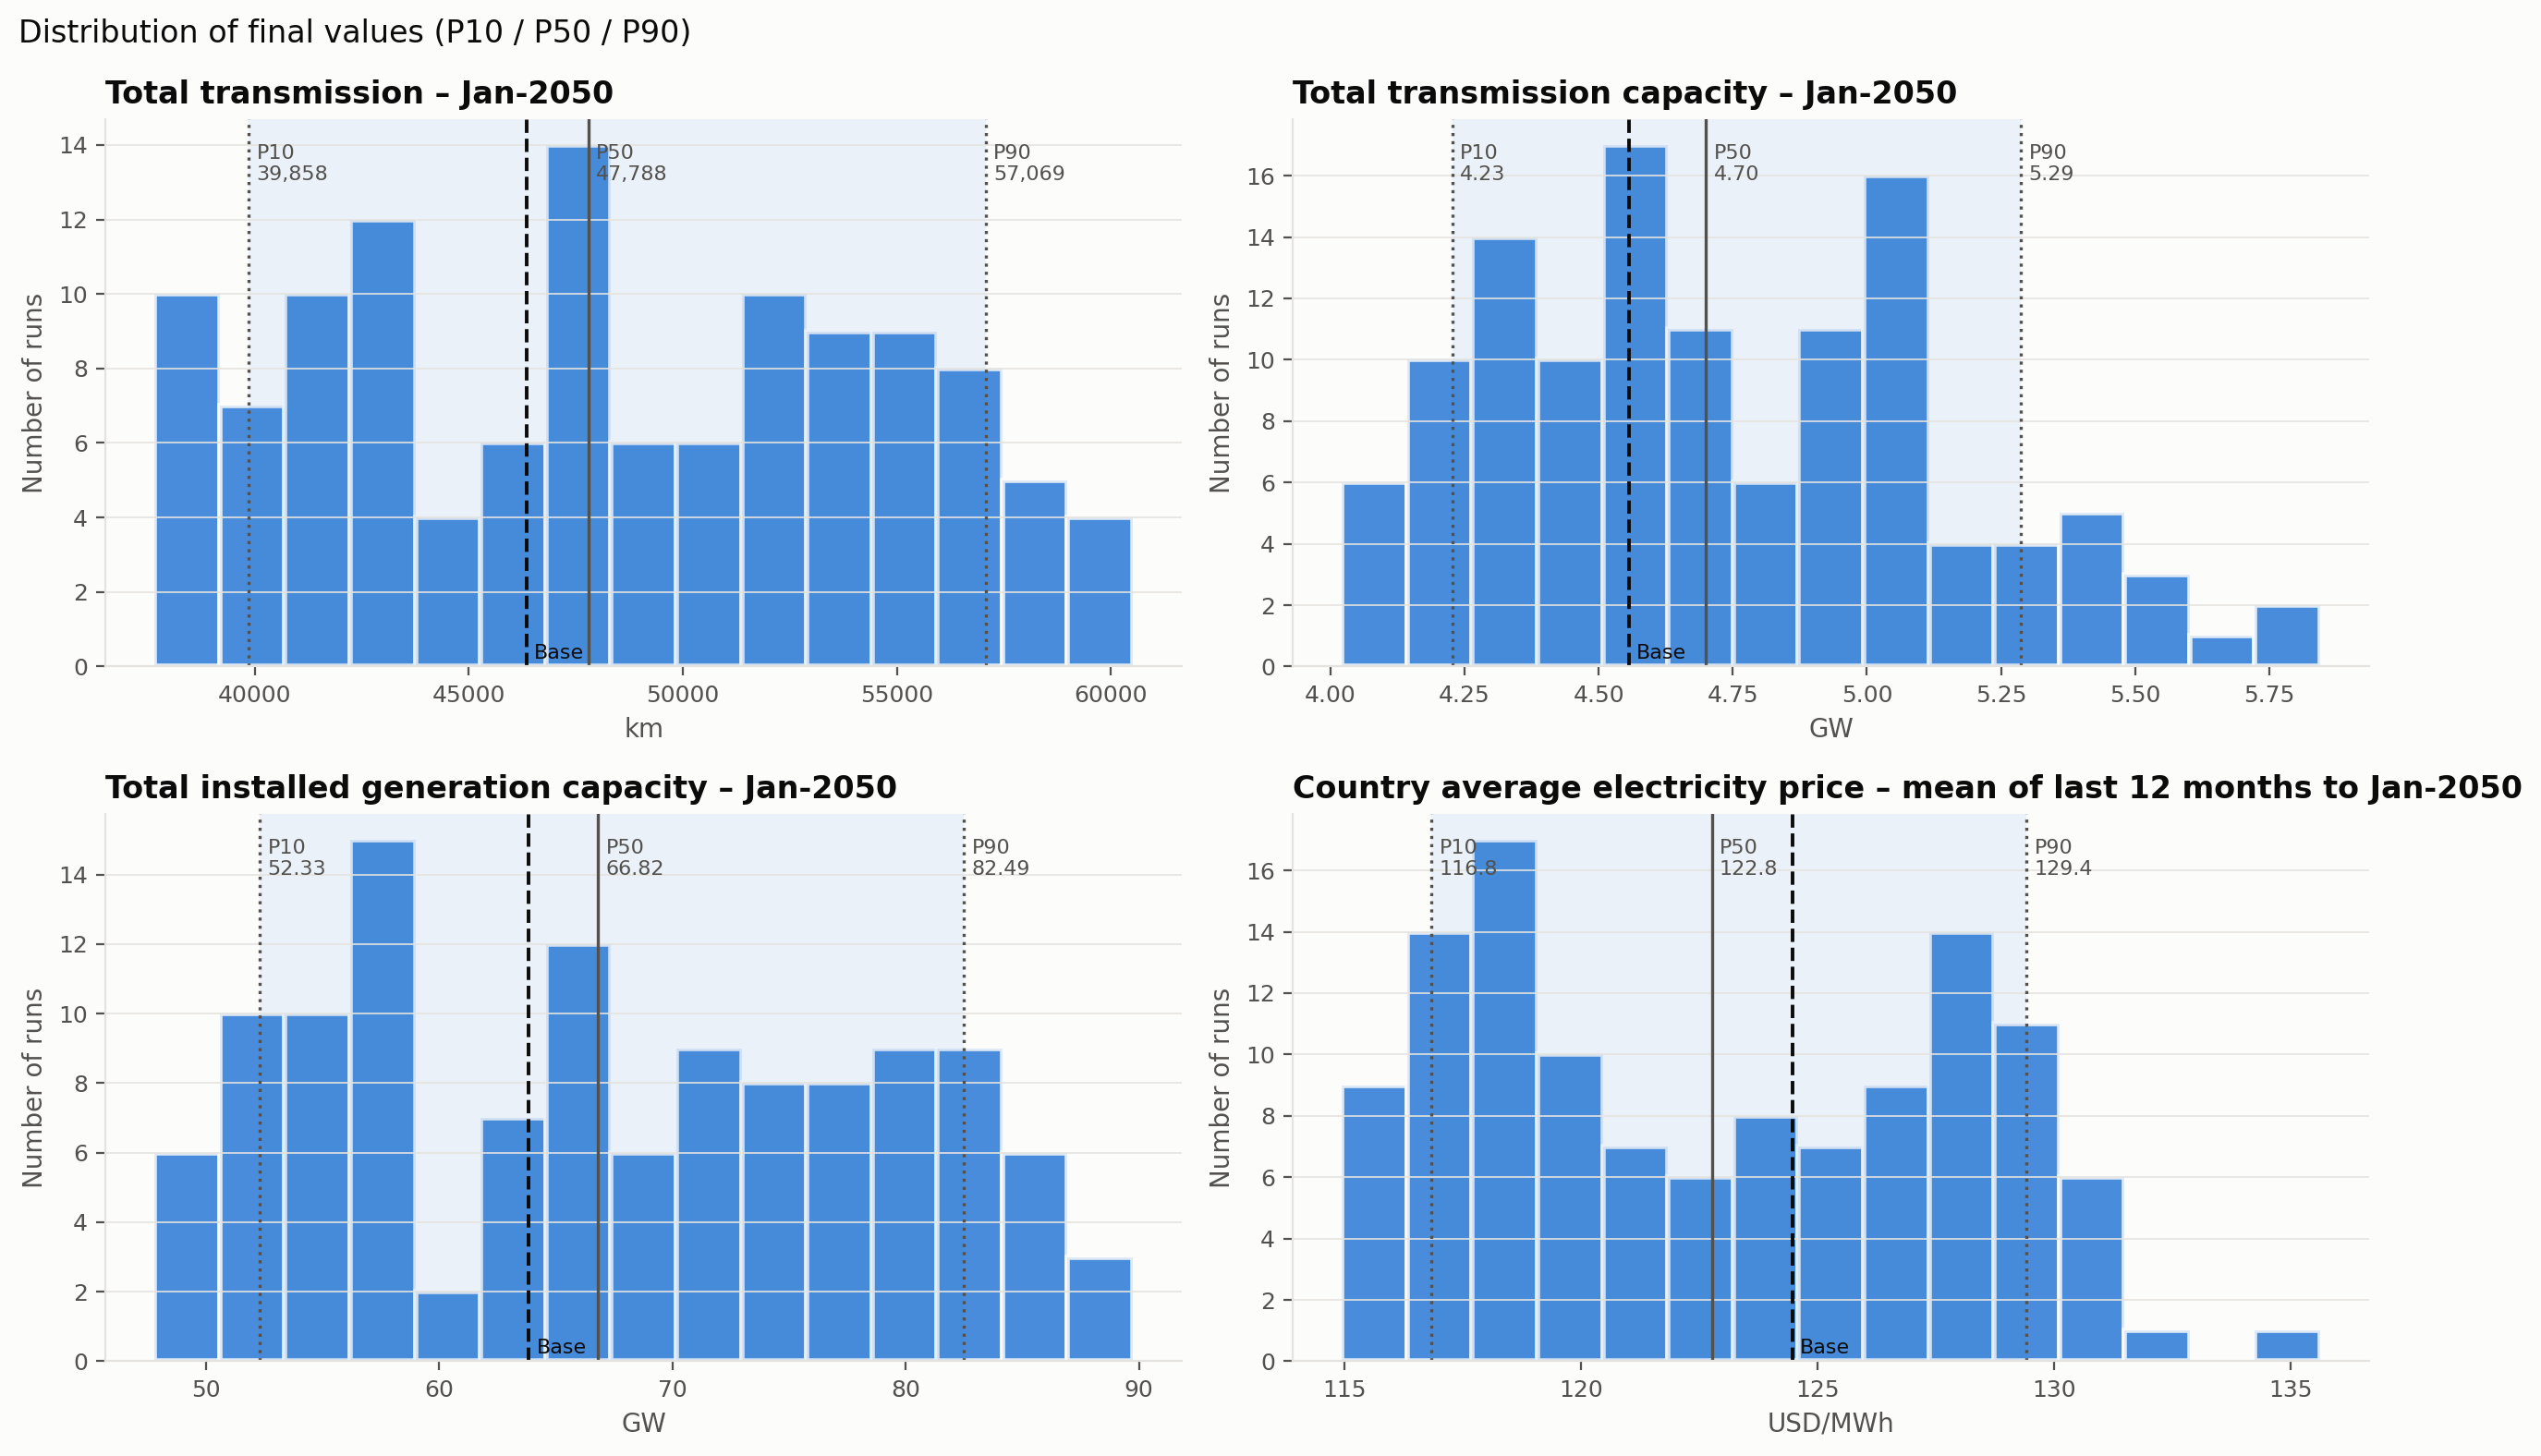

In [12]:
display(Image(filename=str(FIGURES / "02_distribution_P10_P90_histograms.png")))

## 7. The best and the worst case

Chosen among the Monte Carlo runs on one stated metric: the **lowest and the highest
country average electricity price**, where the price is the mean over the last twelve
months of the horizon — it swings month to month with hydrology, so a single month is not
representative. A single declared criterion keeps the selection auditable, which is the
point of reporting two runs in full.

Both are shown against the base case, on a shared axis, so the three are read against each
other rather than in isolation.

In [13]:
mc_ids = [r for r in design.index[design.kind == "montecarlo"] if r in data]
score = -kpi.loc[mc_ids, "price"]
best = score.idxmax()
worst = score.drop(best).idxmin()

extremes = pd.DataFrame({
    "unit": [u for _, u in pt.KPIS.values()],
    f"best ({best})": [kpi.loc[best, k] for k in pt.KPIS],
    "base case": [base[k] for k in pt.KPIS],
    f"worst ({worst})": [kpi.loc[worst, k] for k in pt.KPIS],
    "P10": [np.percentile(kpi.loc[mc_ids, k], 10) for k in pt.KPIS],
    "P90": [np.percentile(kpi.loc[mc_ids, k], 90) for k in pt.KPIS],
}, index=[label for label, _ in pt.KPIS.values()])
display(extremes.style.format(precision=2, subset=list(extremes.columns[1:])))

chosen = pd.DataFrame({
    "range": [f"+/-{pt.FACTORS[k][1]:.0%}" for k in pt.FACTORS],
    f"best ({best})": [design.loc[best, k] for k in pt.FACTORS],
    f"worst ({worst})": [design.loc[worst, k] for k in pt.FACTORS],
}, index=[pt.FACTORS[k][2] for k in pt.FACTORS])
display(chosen.style.format(precision=4, subset=list(chosen.columns[1:])))

,unit,best (mc_009),base case,worst (mc_058),P10,P90
Total transmission,km,58561.73,46341.23,38927.13,39857.99,57068.70
Total transmission capacity,GW,5.03,4.56,4.34,4.23,5.29
Total installed generation capacity,GW,86.40,63.85,49.18,52.33,82.49
Country average electricity price,USD/MWh,114.94,124.46,135.63,116.83,129.42


,range,best (mc_009),worst (mc_058)
Generation project delays,+/-20%,0.0985,-0.0539
Transmission project delays,+/-20%,0.0263,0.0824
Fuel prices,+/-15%,-0.0251,-0.0106
Demand growth,+/-20%,0.1728,-0.1646


### Electricity price

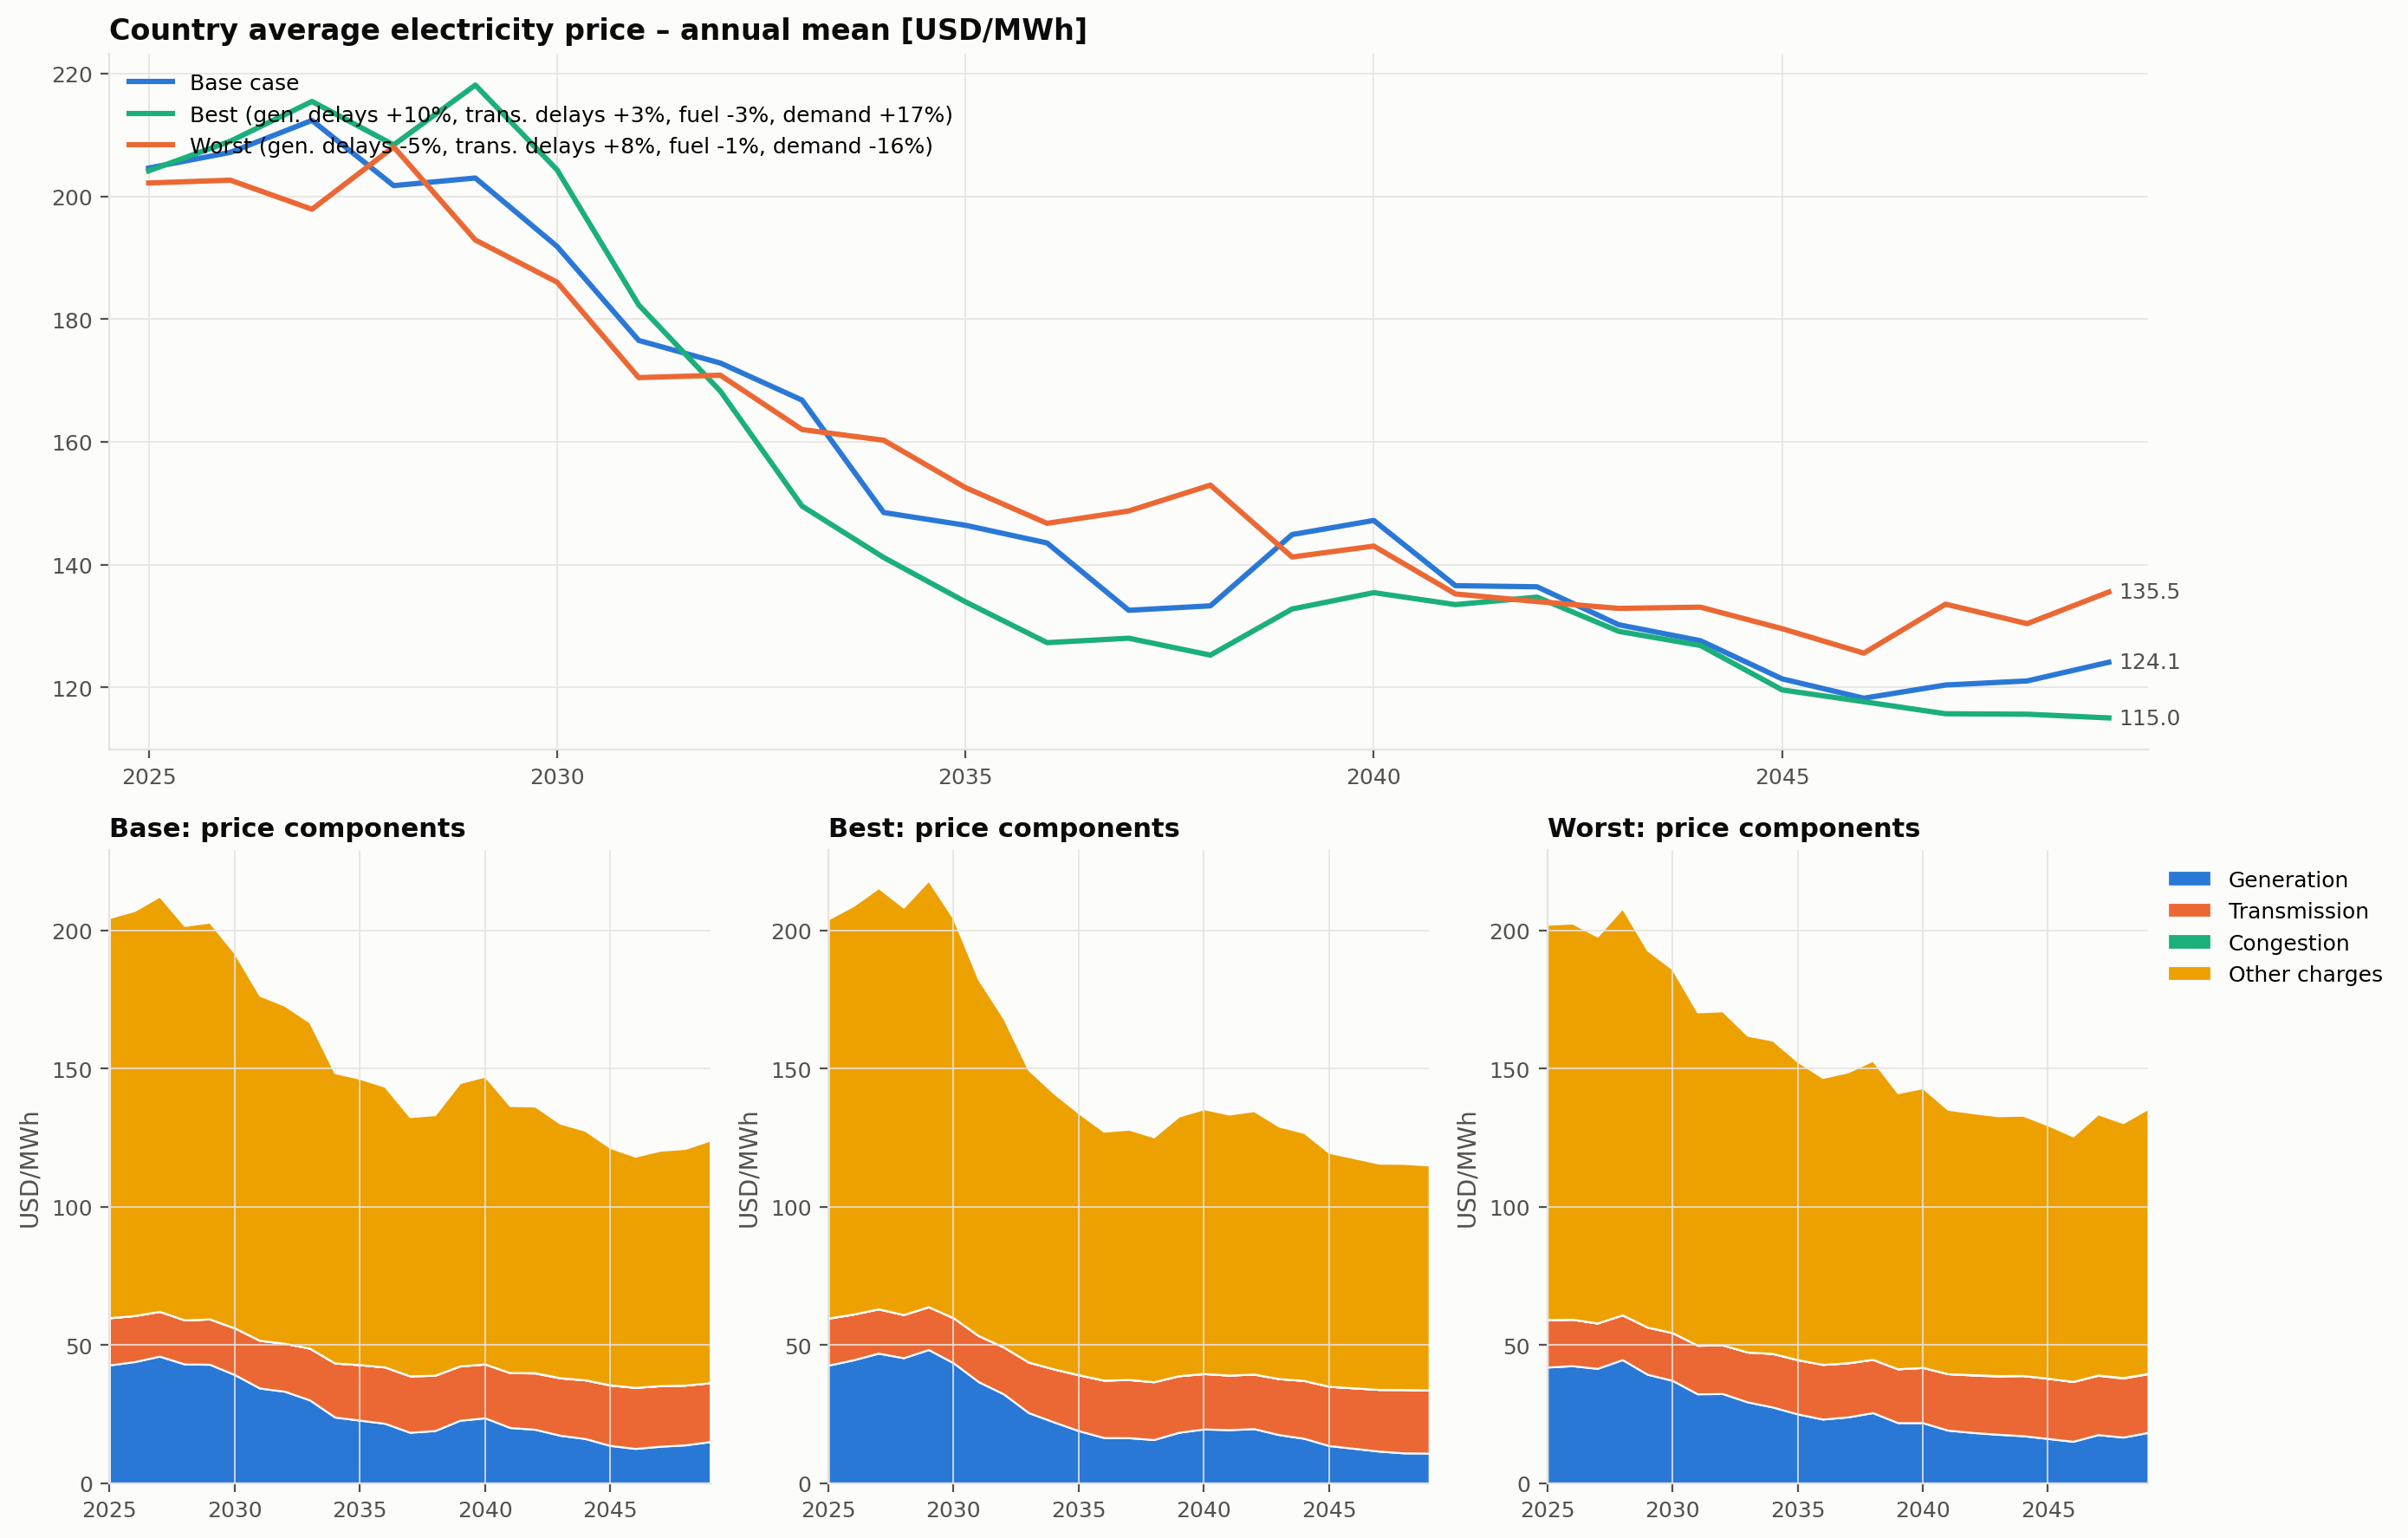

In [14]:
display(Image(filename=str(FIGURES / "04_price_best_worst.png")))

### Installed capacity by technology

The 14 model technologies are grouped into 8 plotted series, because a stacked chart stops
being readable past eight bands. A technology keeps its colour across every figure and
every scenario, so colour follows the entity, never its rank.

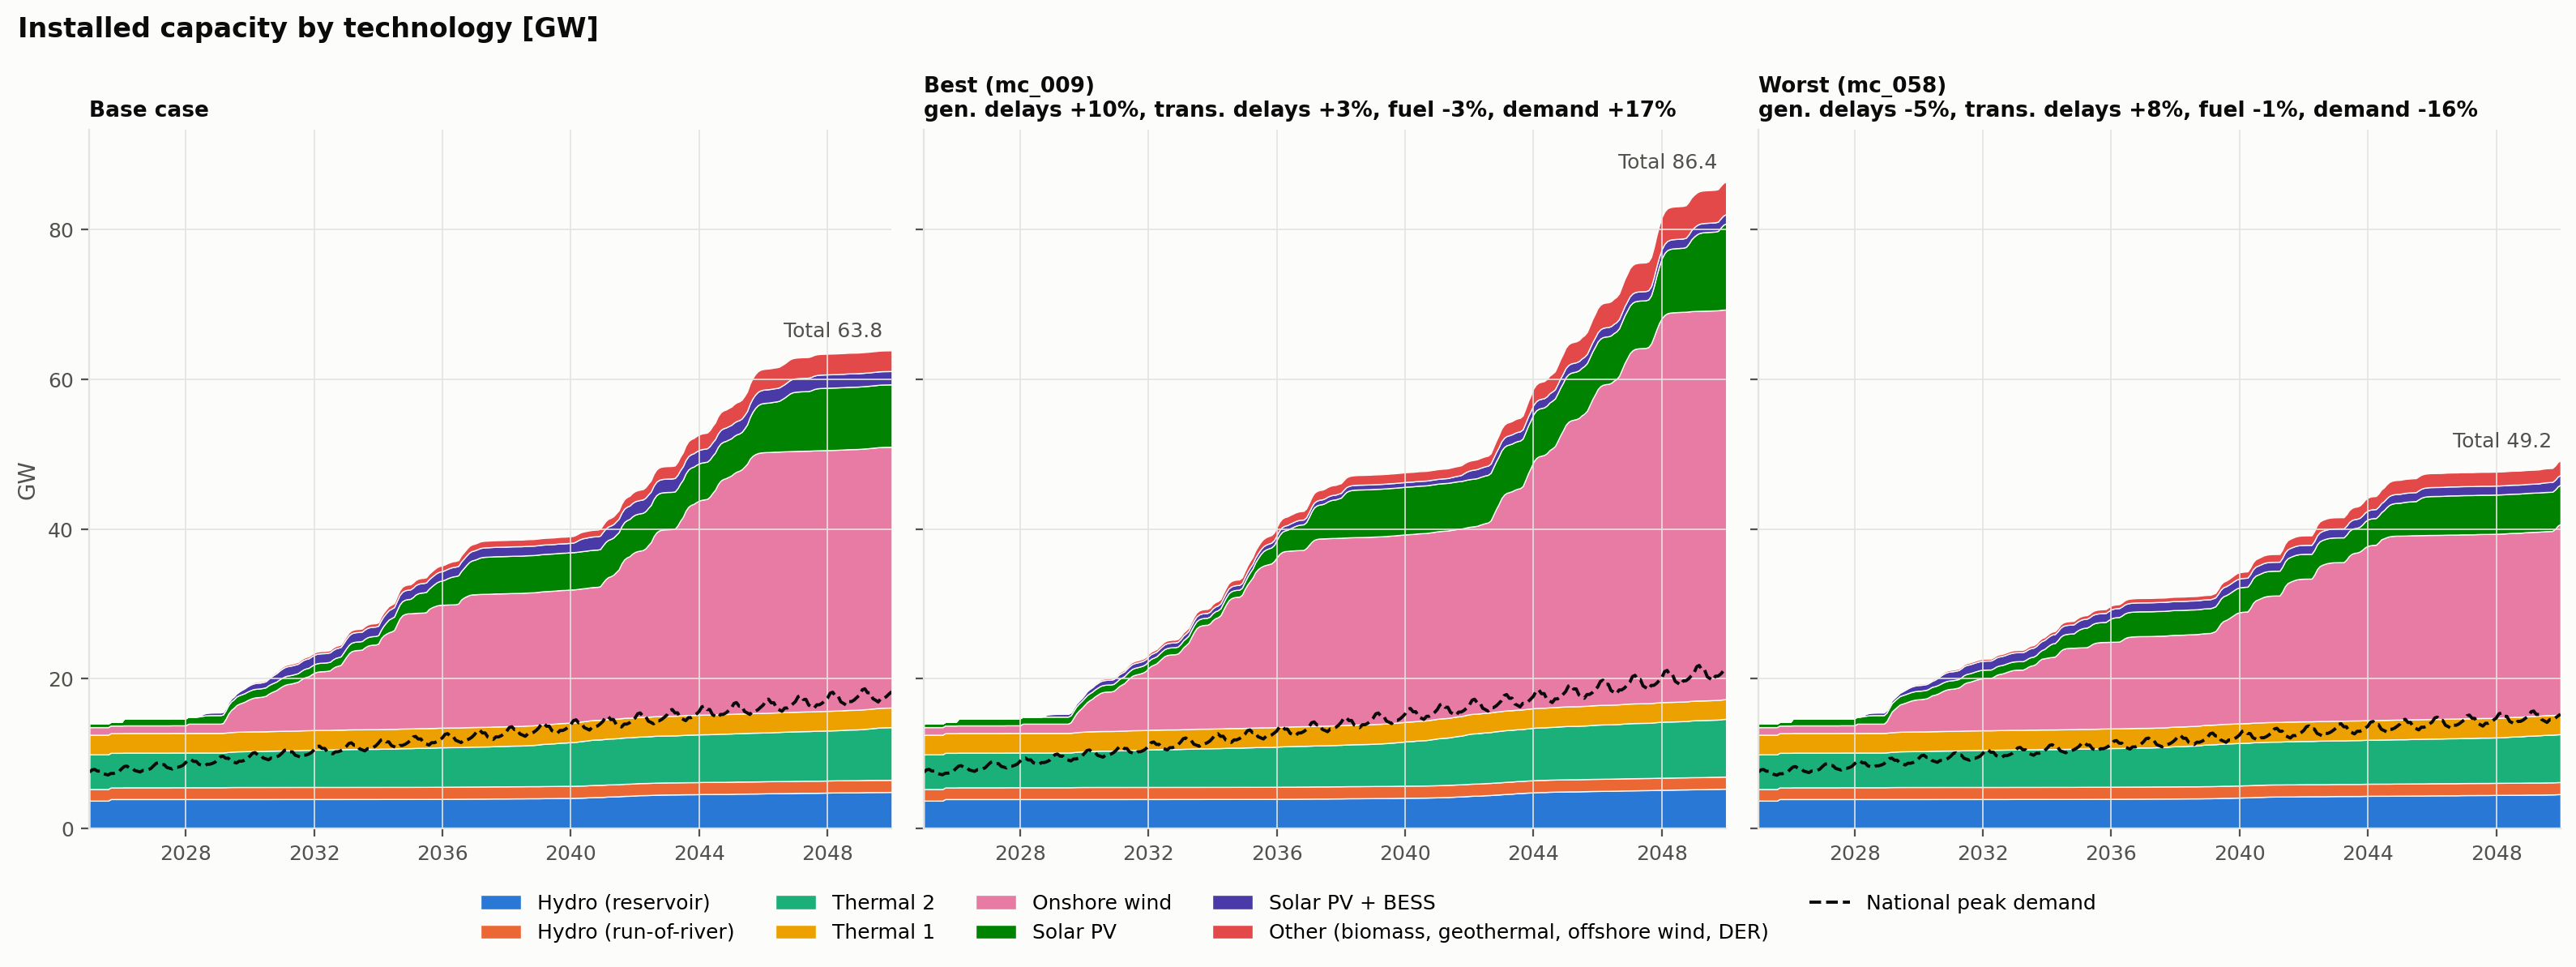

In [15]:
display(Image(filename=str(FIGURES / "05_installed_capacity_by_technology.png")))

### Electricity generation by technology

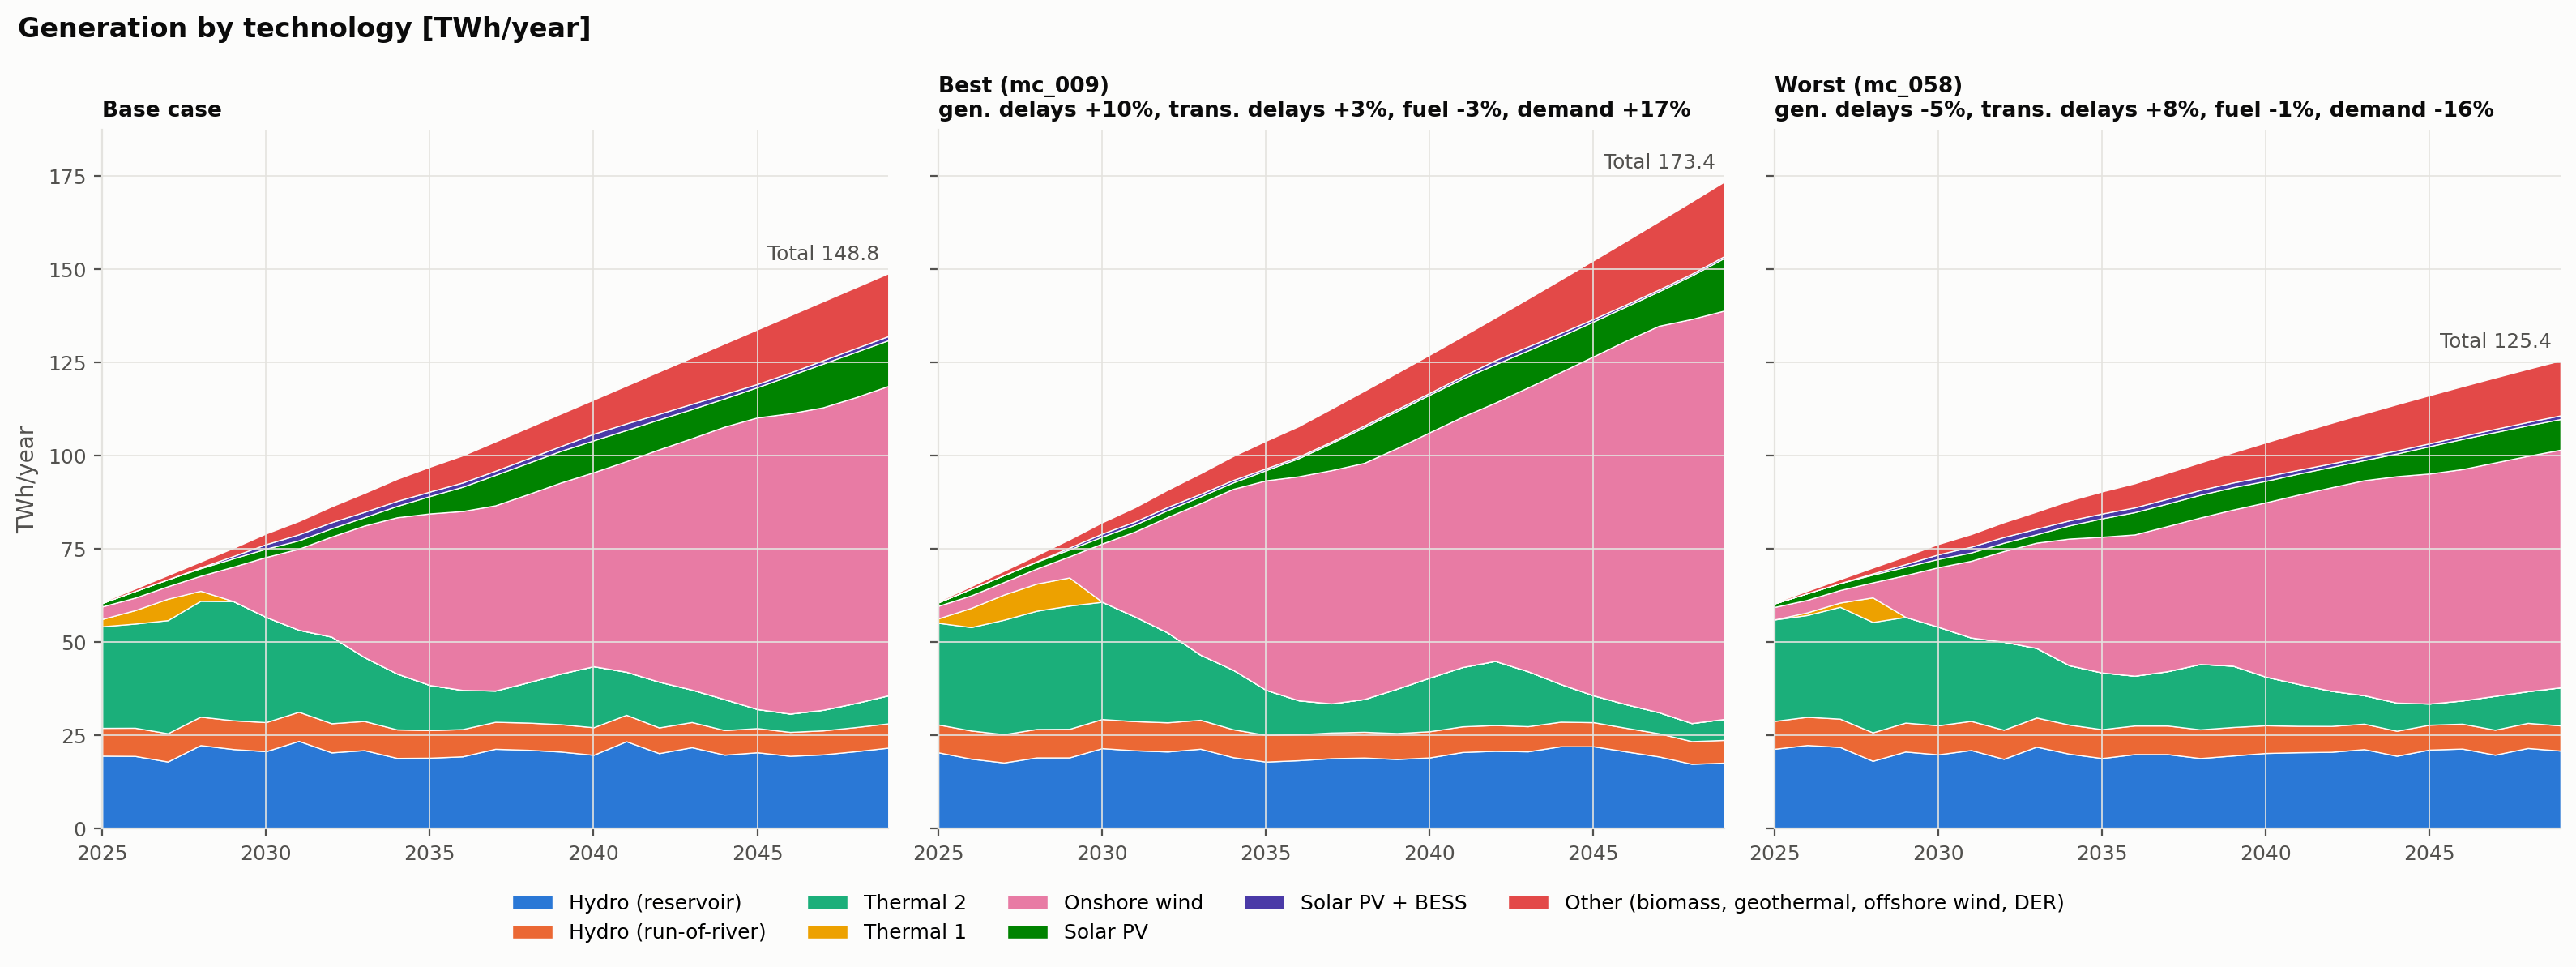

In [16]:
display(Image(filename=str(FIGURES / "06_generation_by_technology.png")))

### Transmission

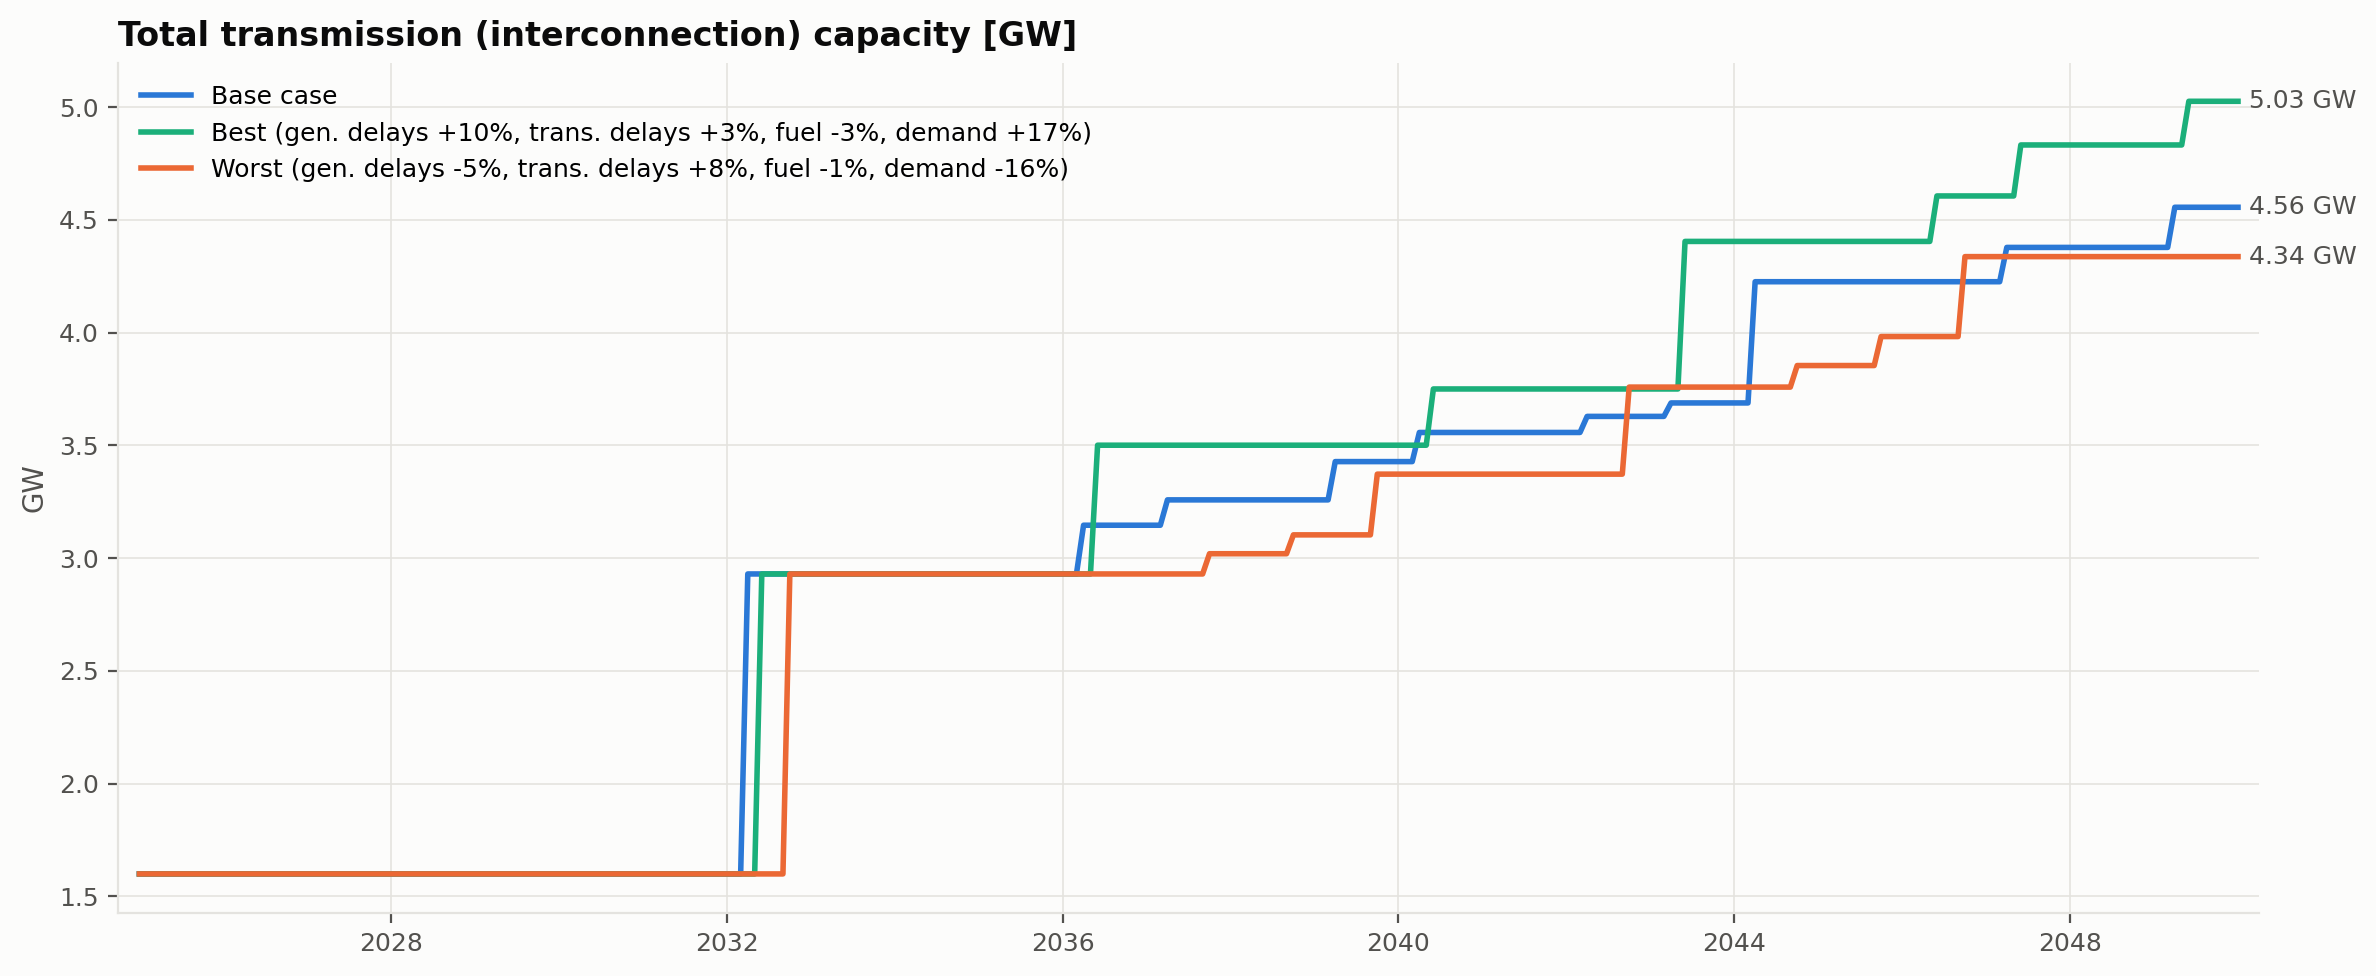

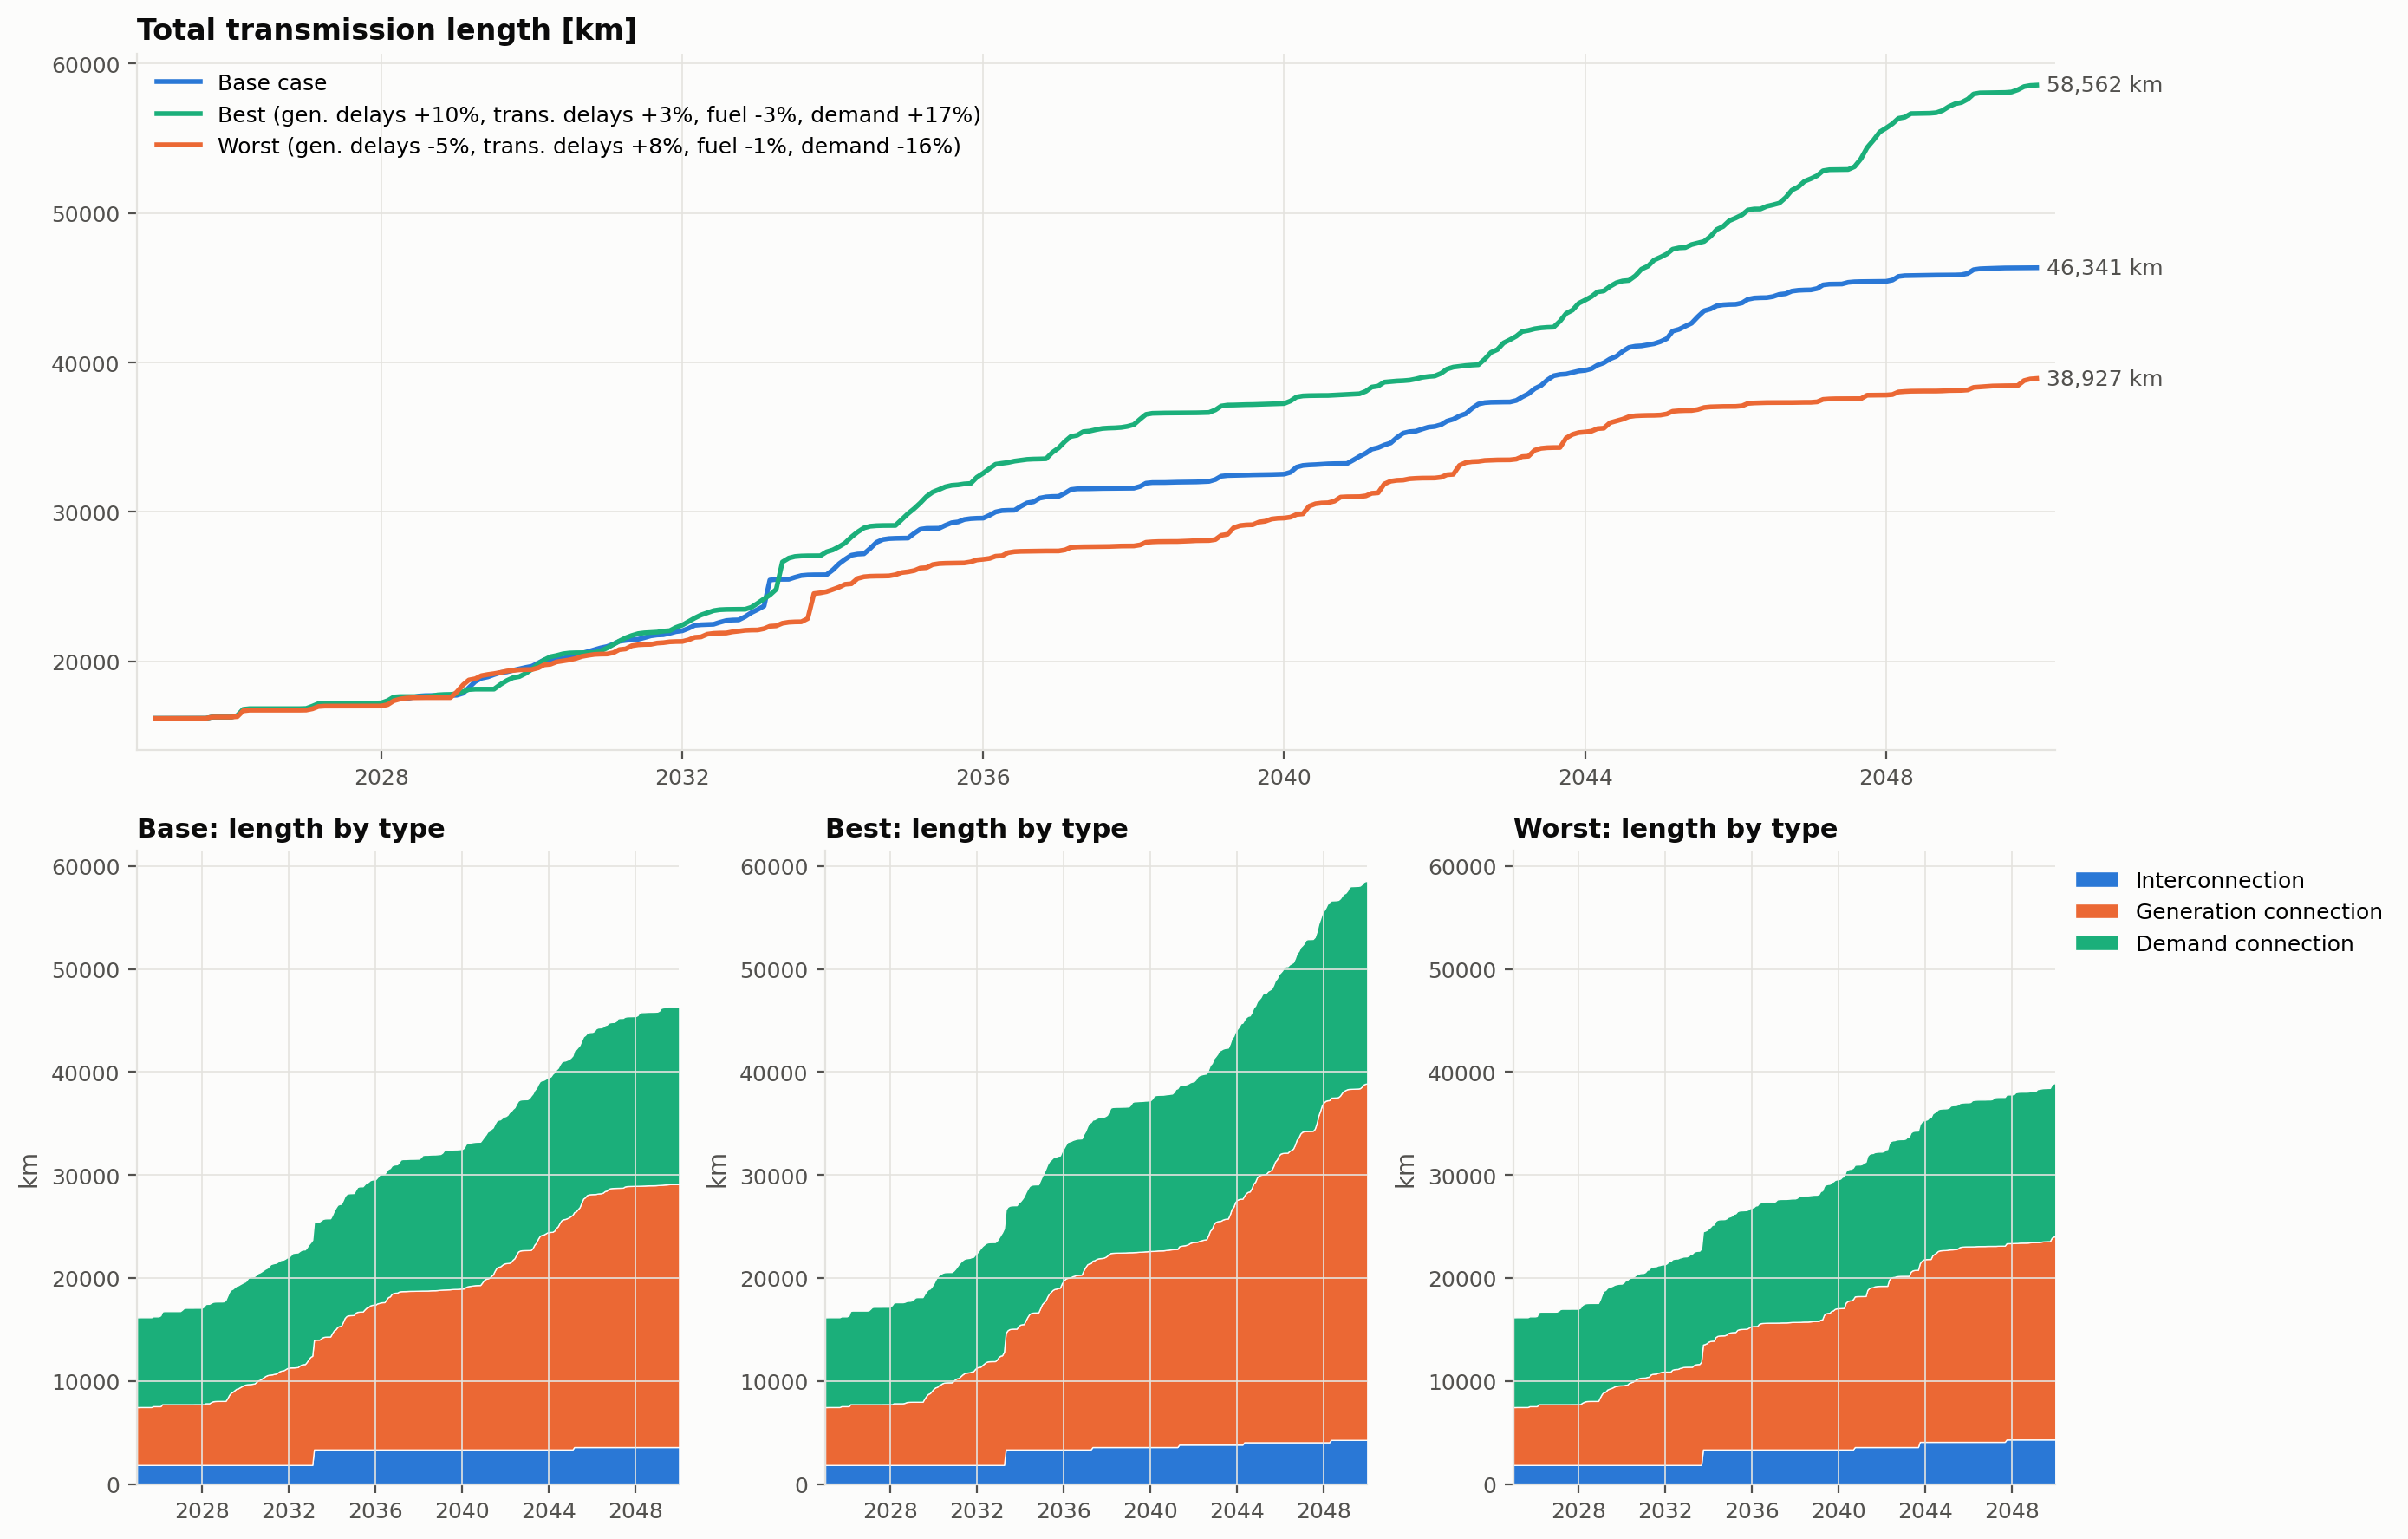

In [17]:
for name in ("07_transmission_capacity_GW.png", "08_transmission_km.png"):
    display(Image(filename=str(FIGURES / name)))

## 8. Method checks

Three questions a reviewer will ask, answered with figures rather than assurances.

**Is the sample well spread?** (`09`) The design, projected onto each pair of factors.

**Are 120 runs enough?** (`10`) P10, P50 and P90 recomputed from growing subsets of the
Monte Carlo runs. If they have stopped moving, the sample is large enough — and if
they have not, that is the finding.

**Which factor dominates when everything moves at once?** (`11`) Spearman rank correlation
between each factor and each KPI over the Monte Carlo runs: −1 to +1, near zero means no
influence. This is the complement to the tornado, which moves one factor at a time.

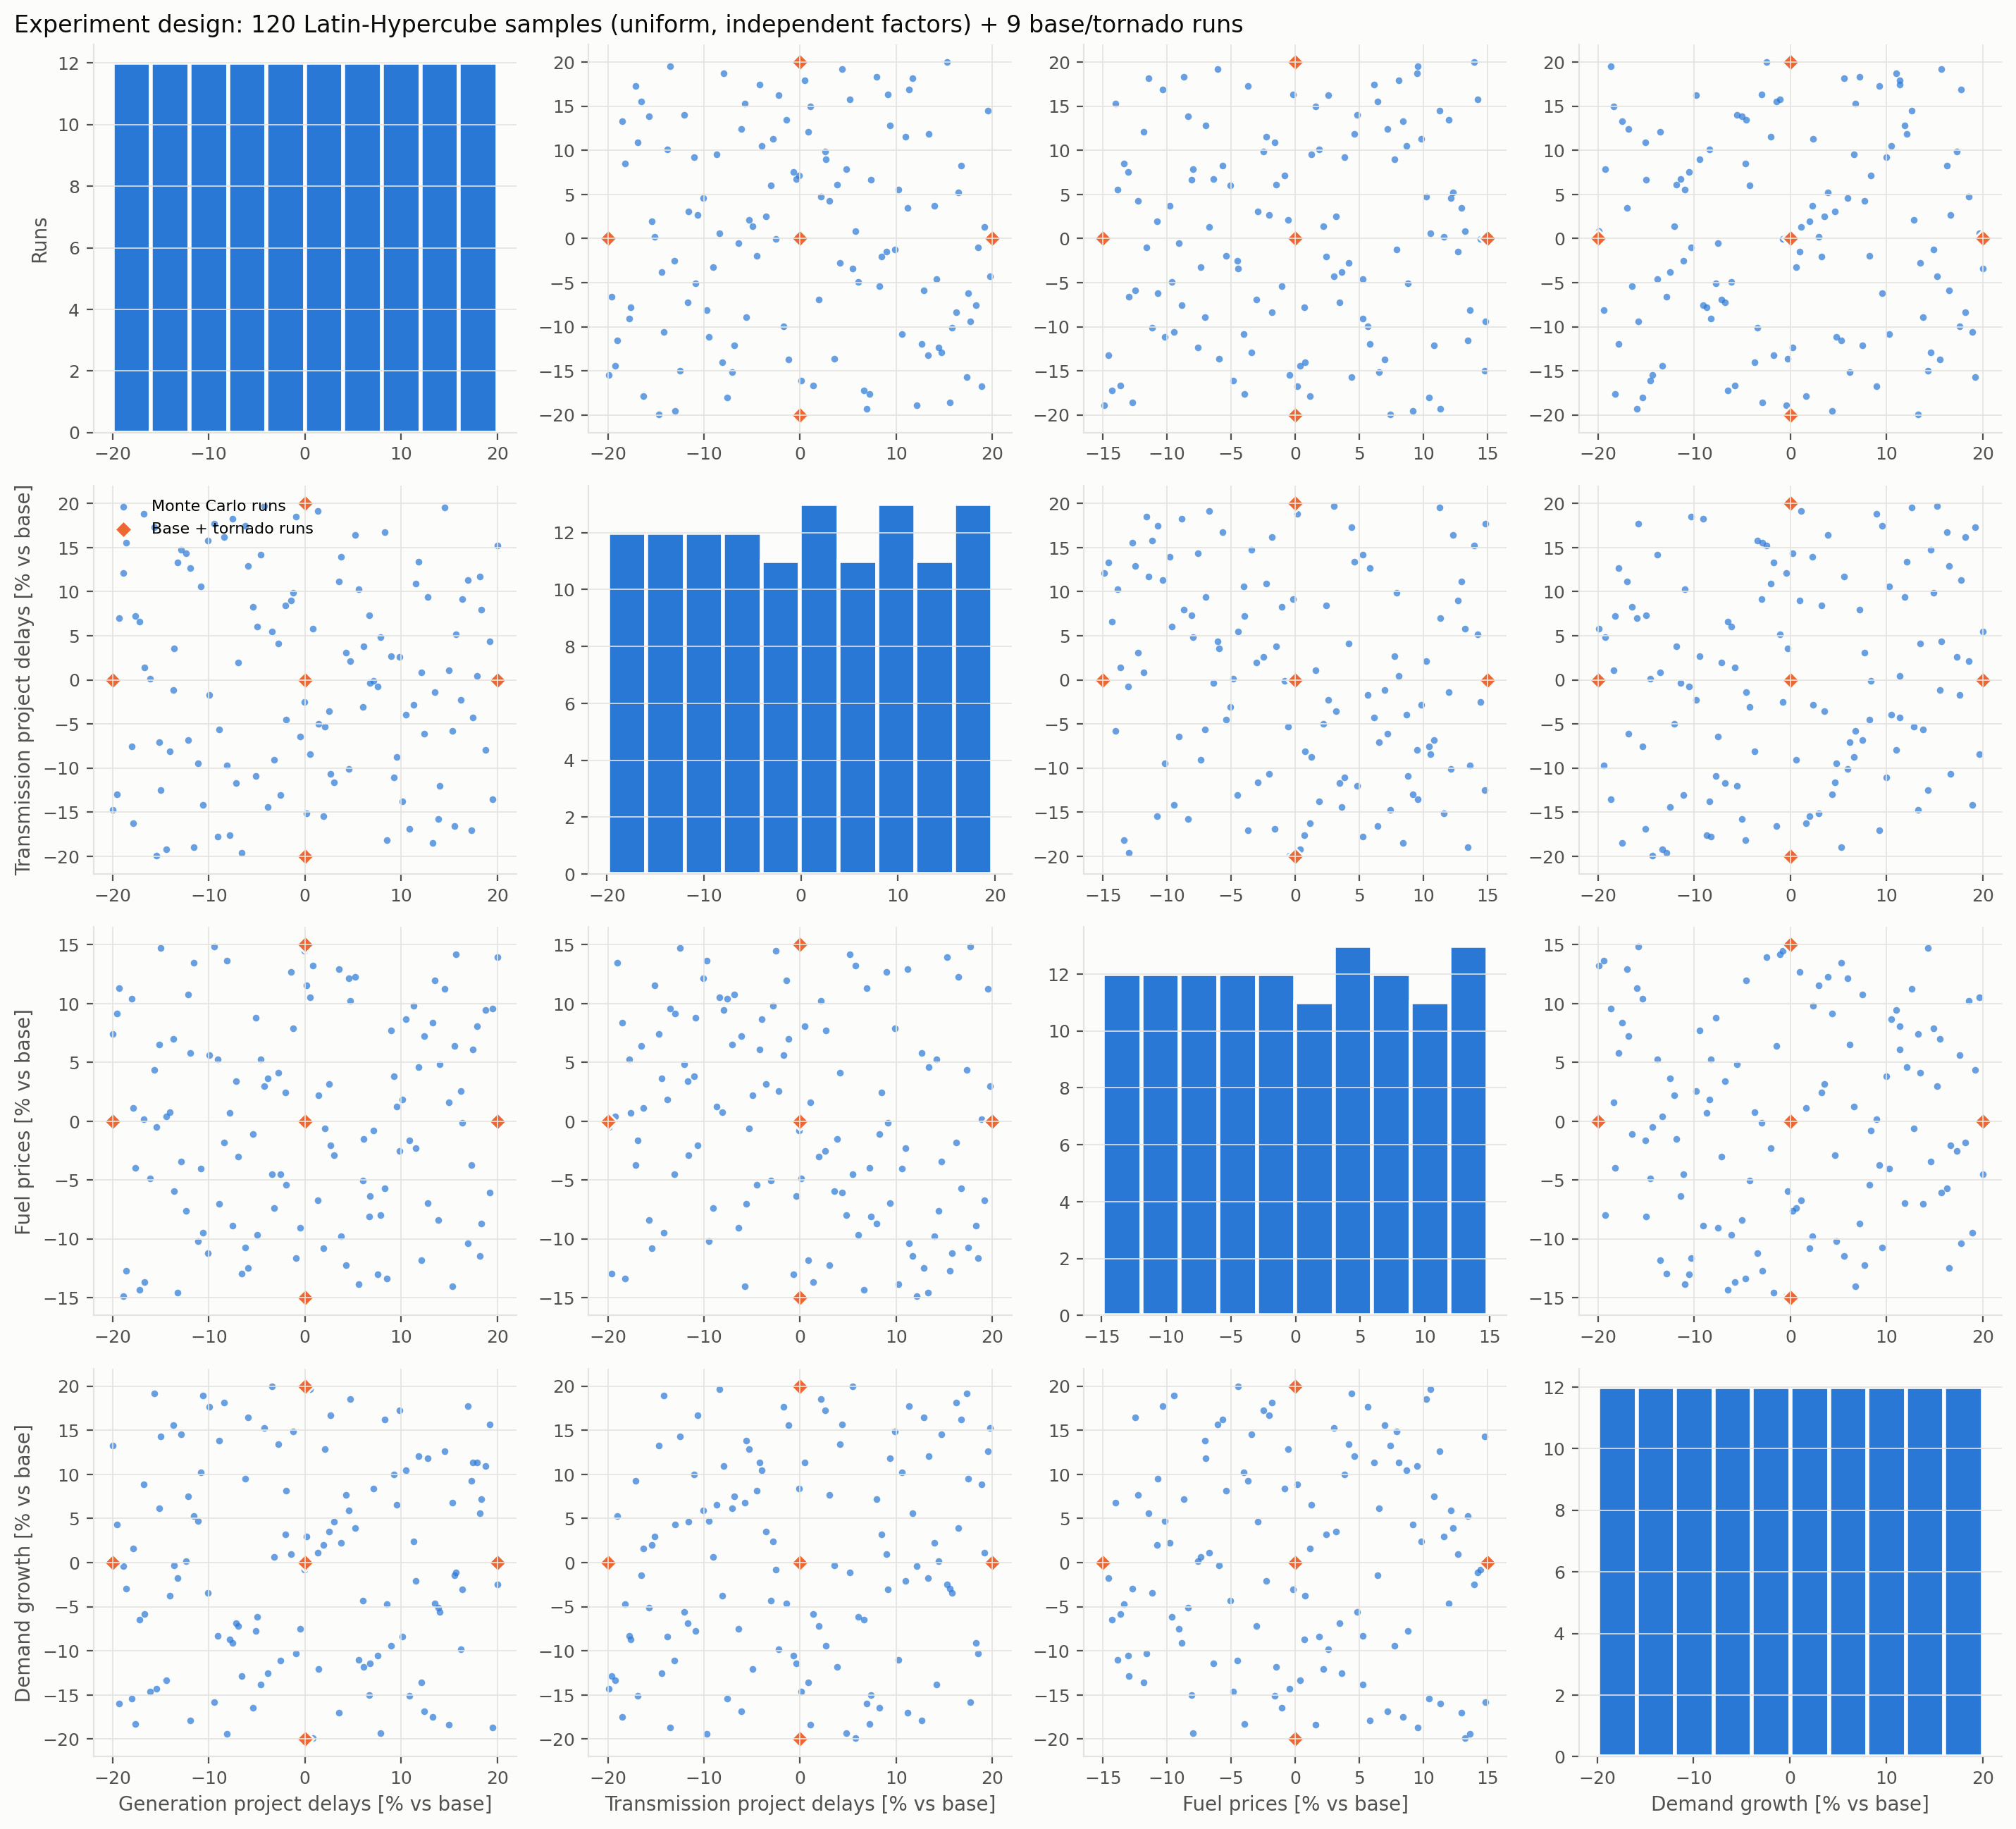

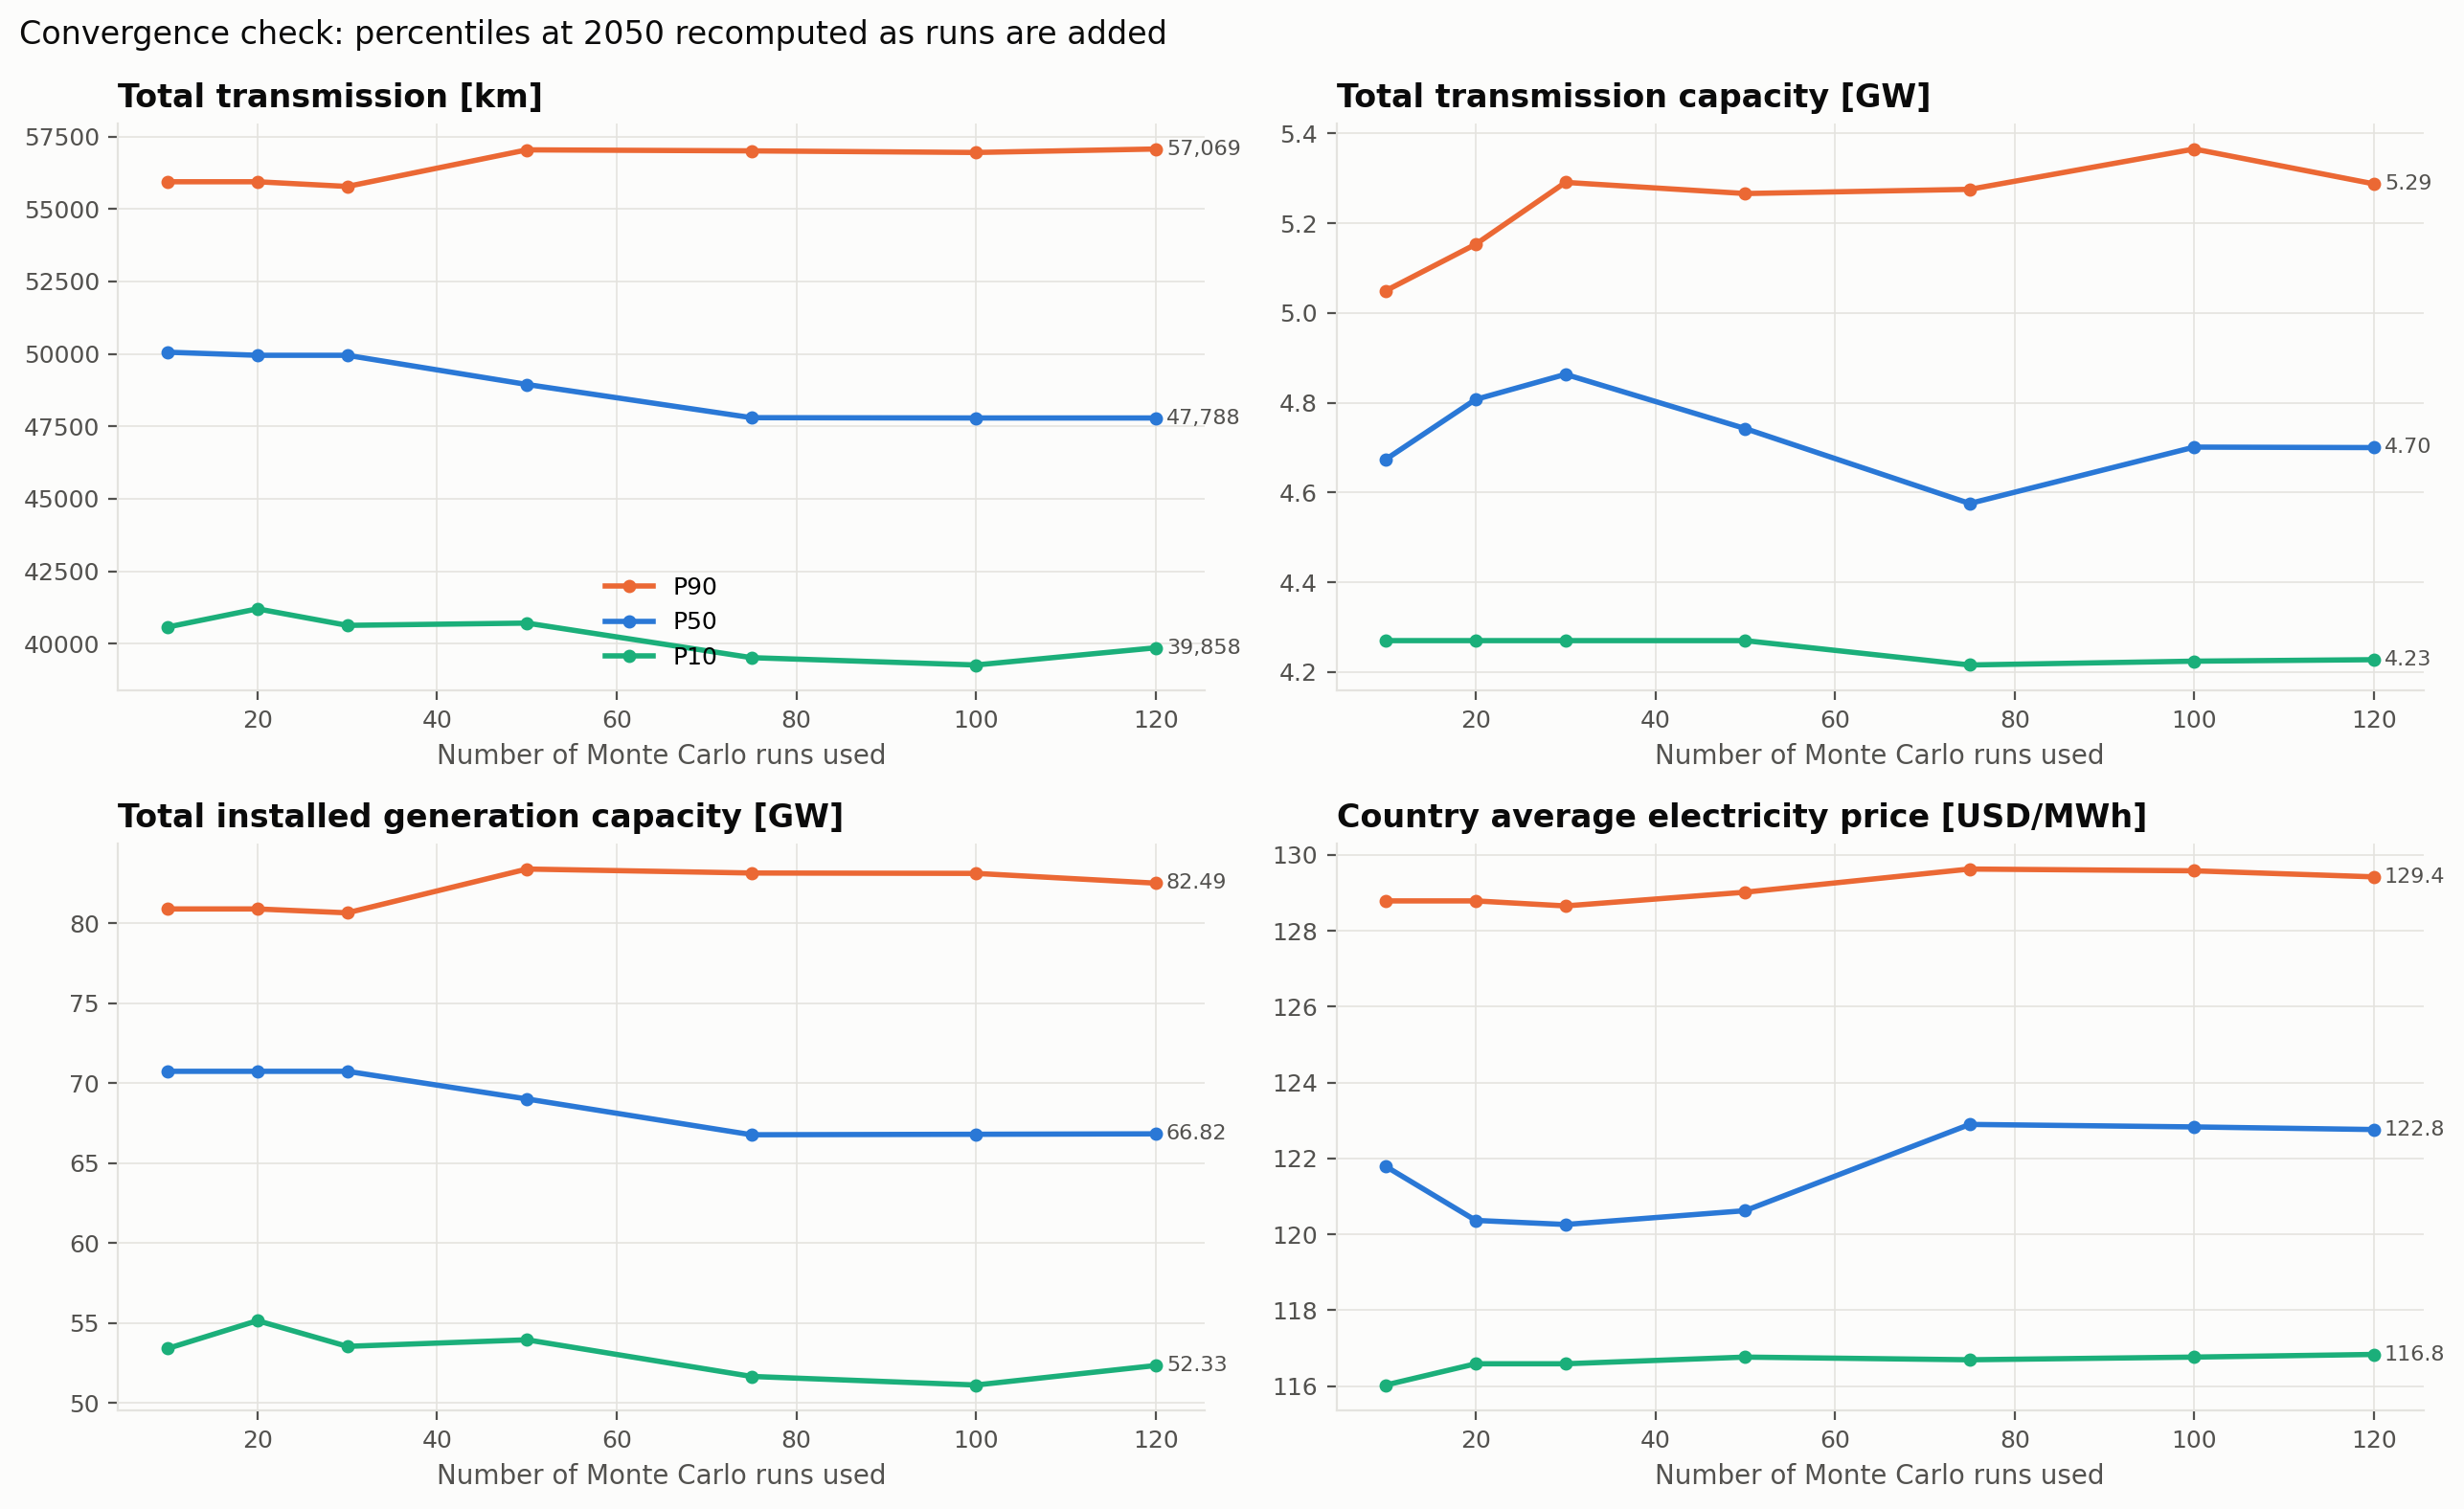

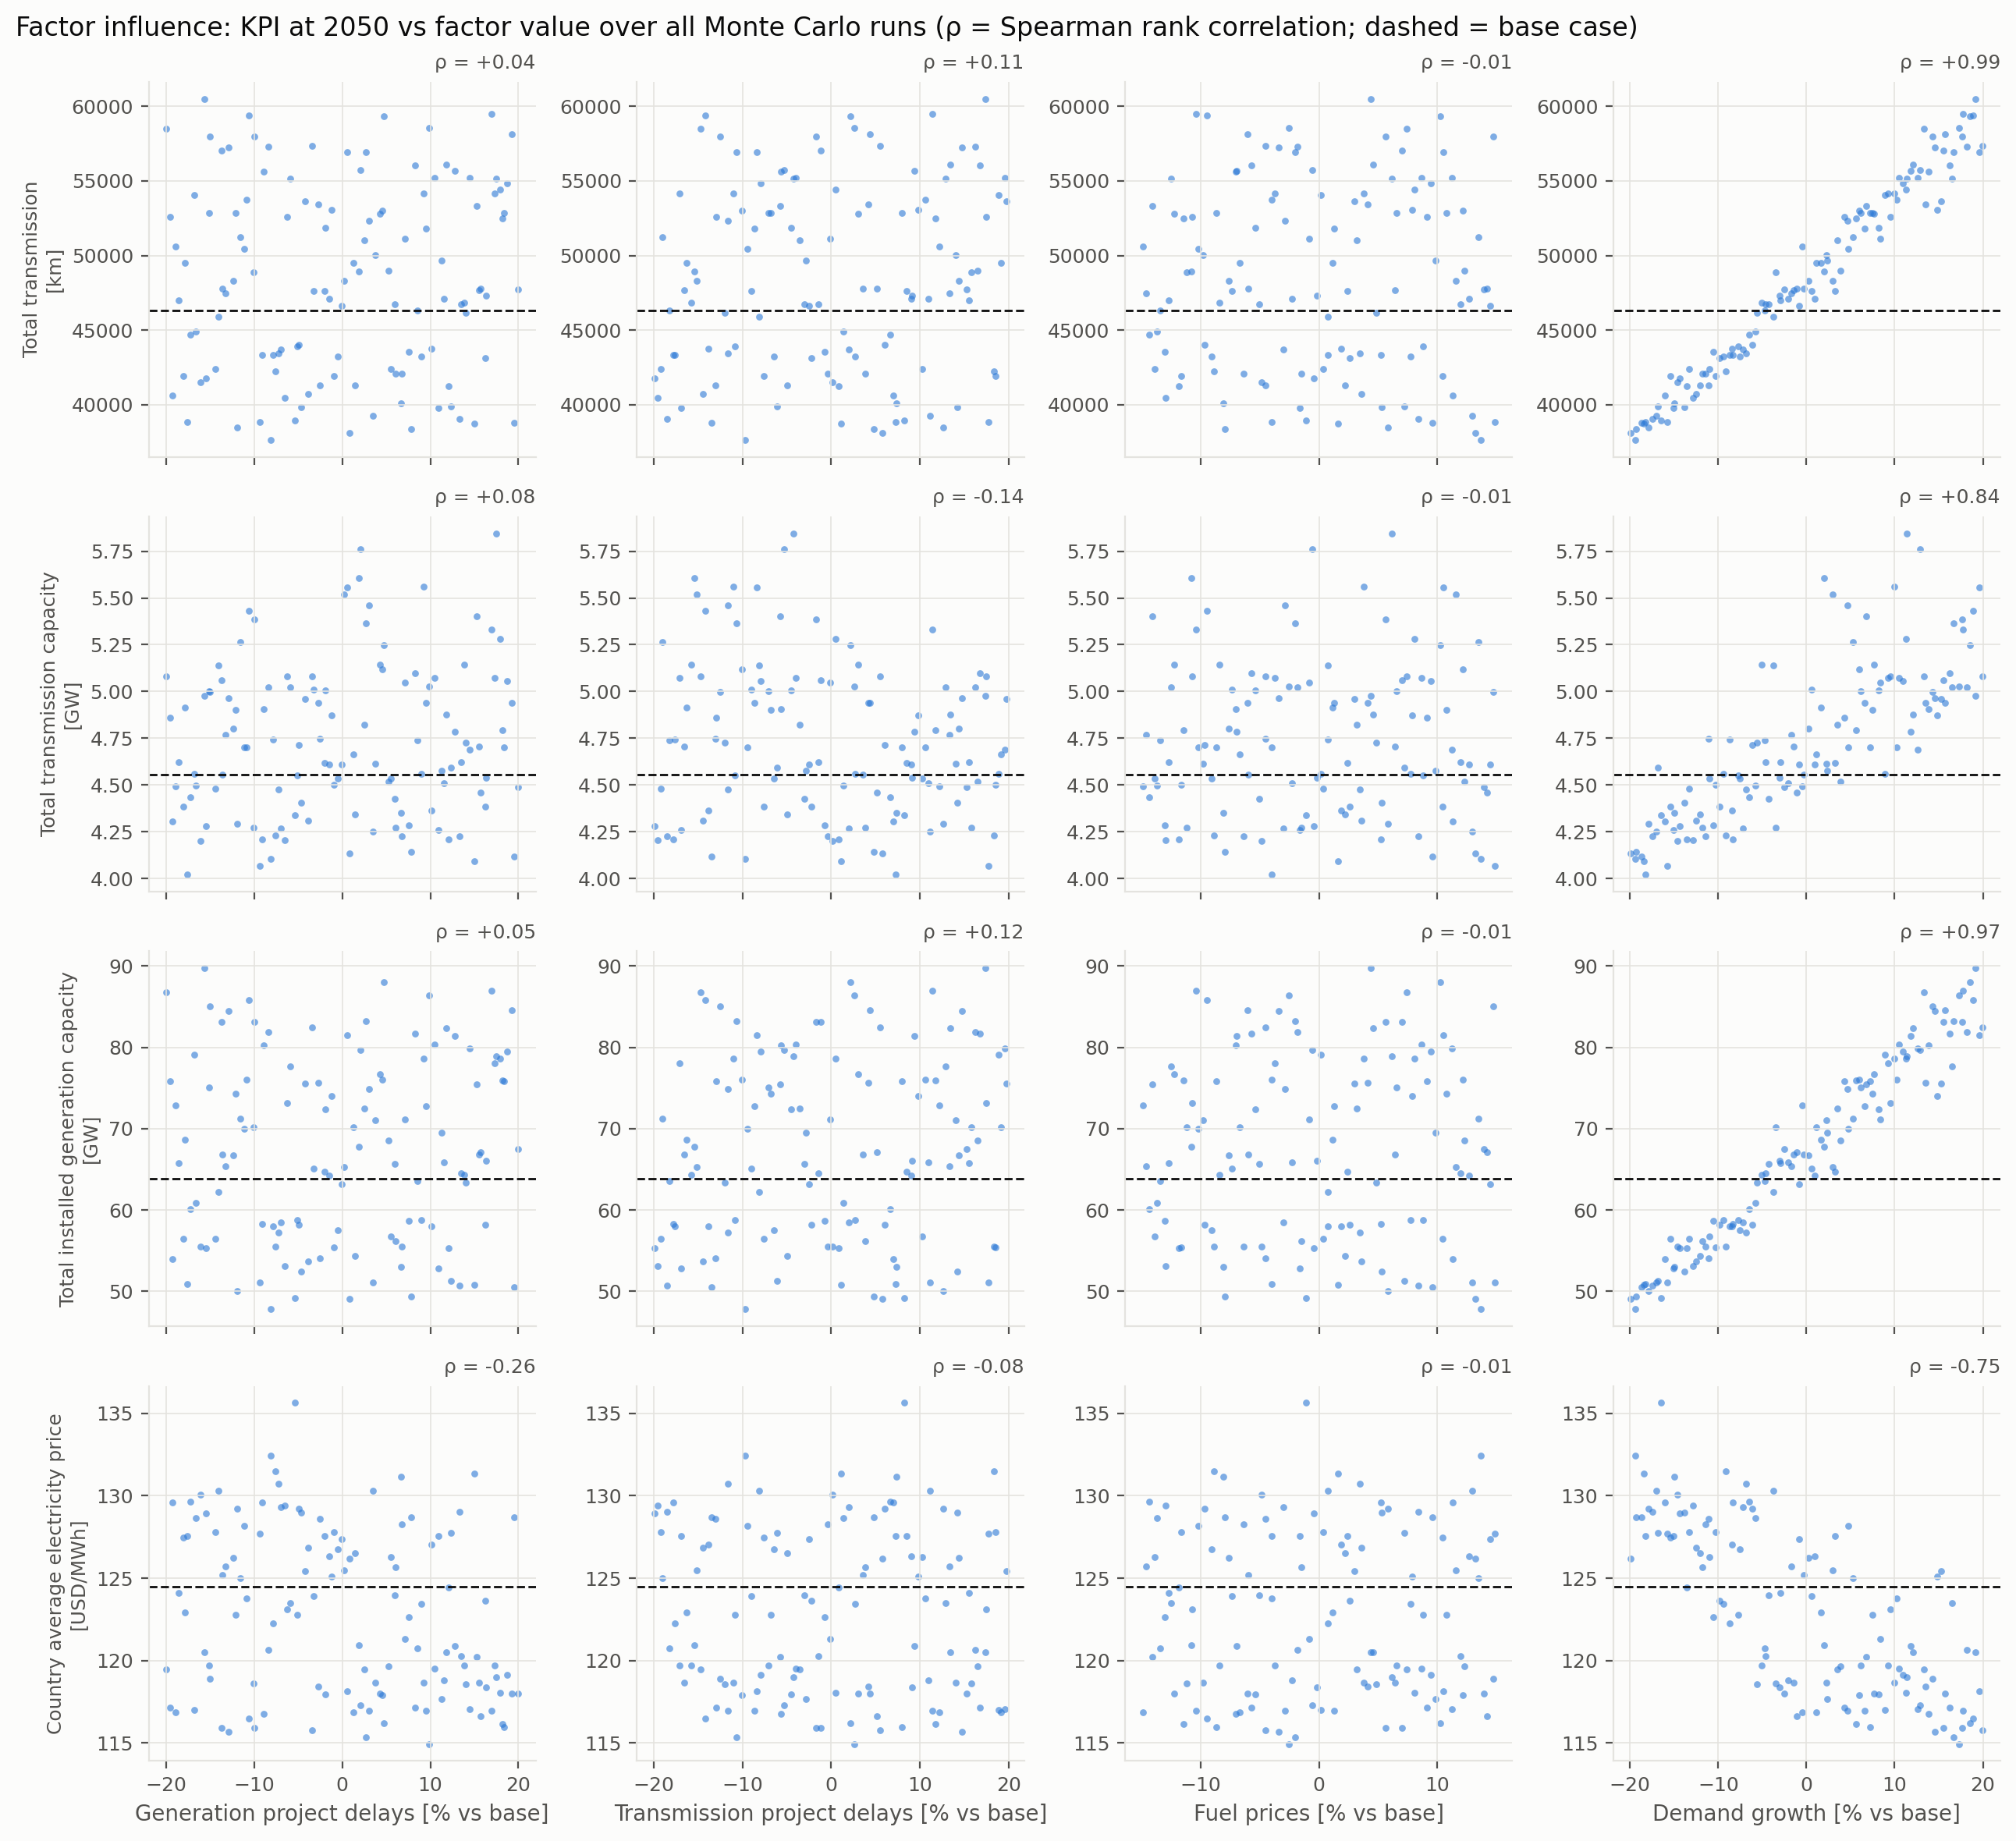

In [18]:
for name in ("09_sampling_design.png", "10_convergence.png", "11_factor_influence.png"):
    display(Image(filename=str(FIGURES / name)))

## 9. Tables for the paper

`tornado_summary.xlsx` carries one sheet per product: a README sheet explaining the rest,
the best/worst scenarios, the P10–P90 distribution, the tornado table, every run's KPIs,
the convergence check and the rank correlations. `00_summary_table.png` is the same content
as a figure.

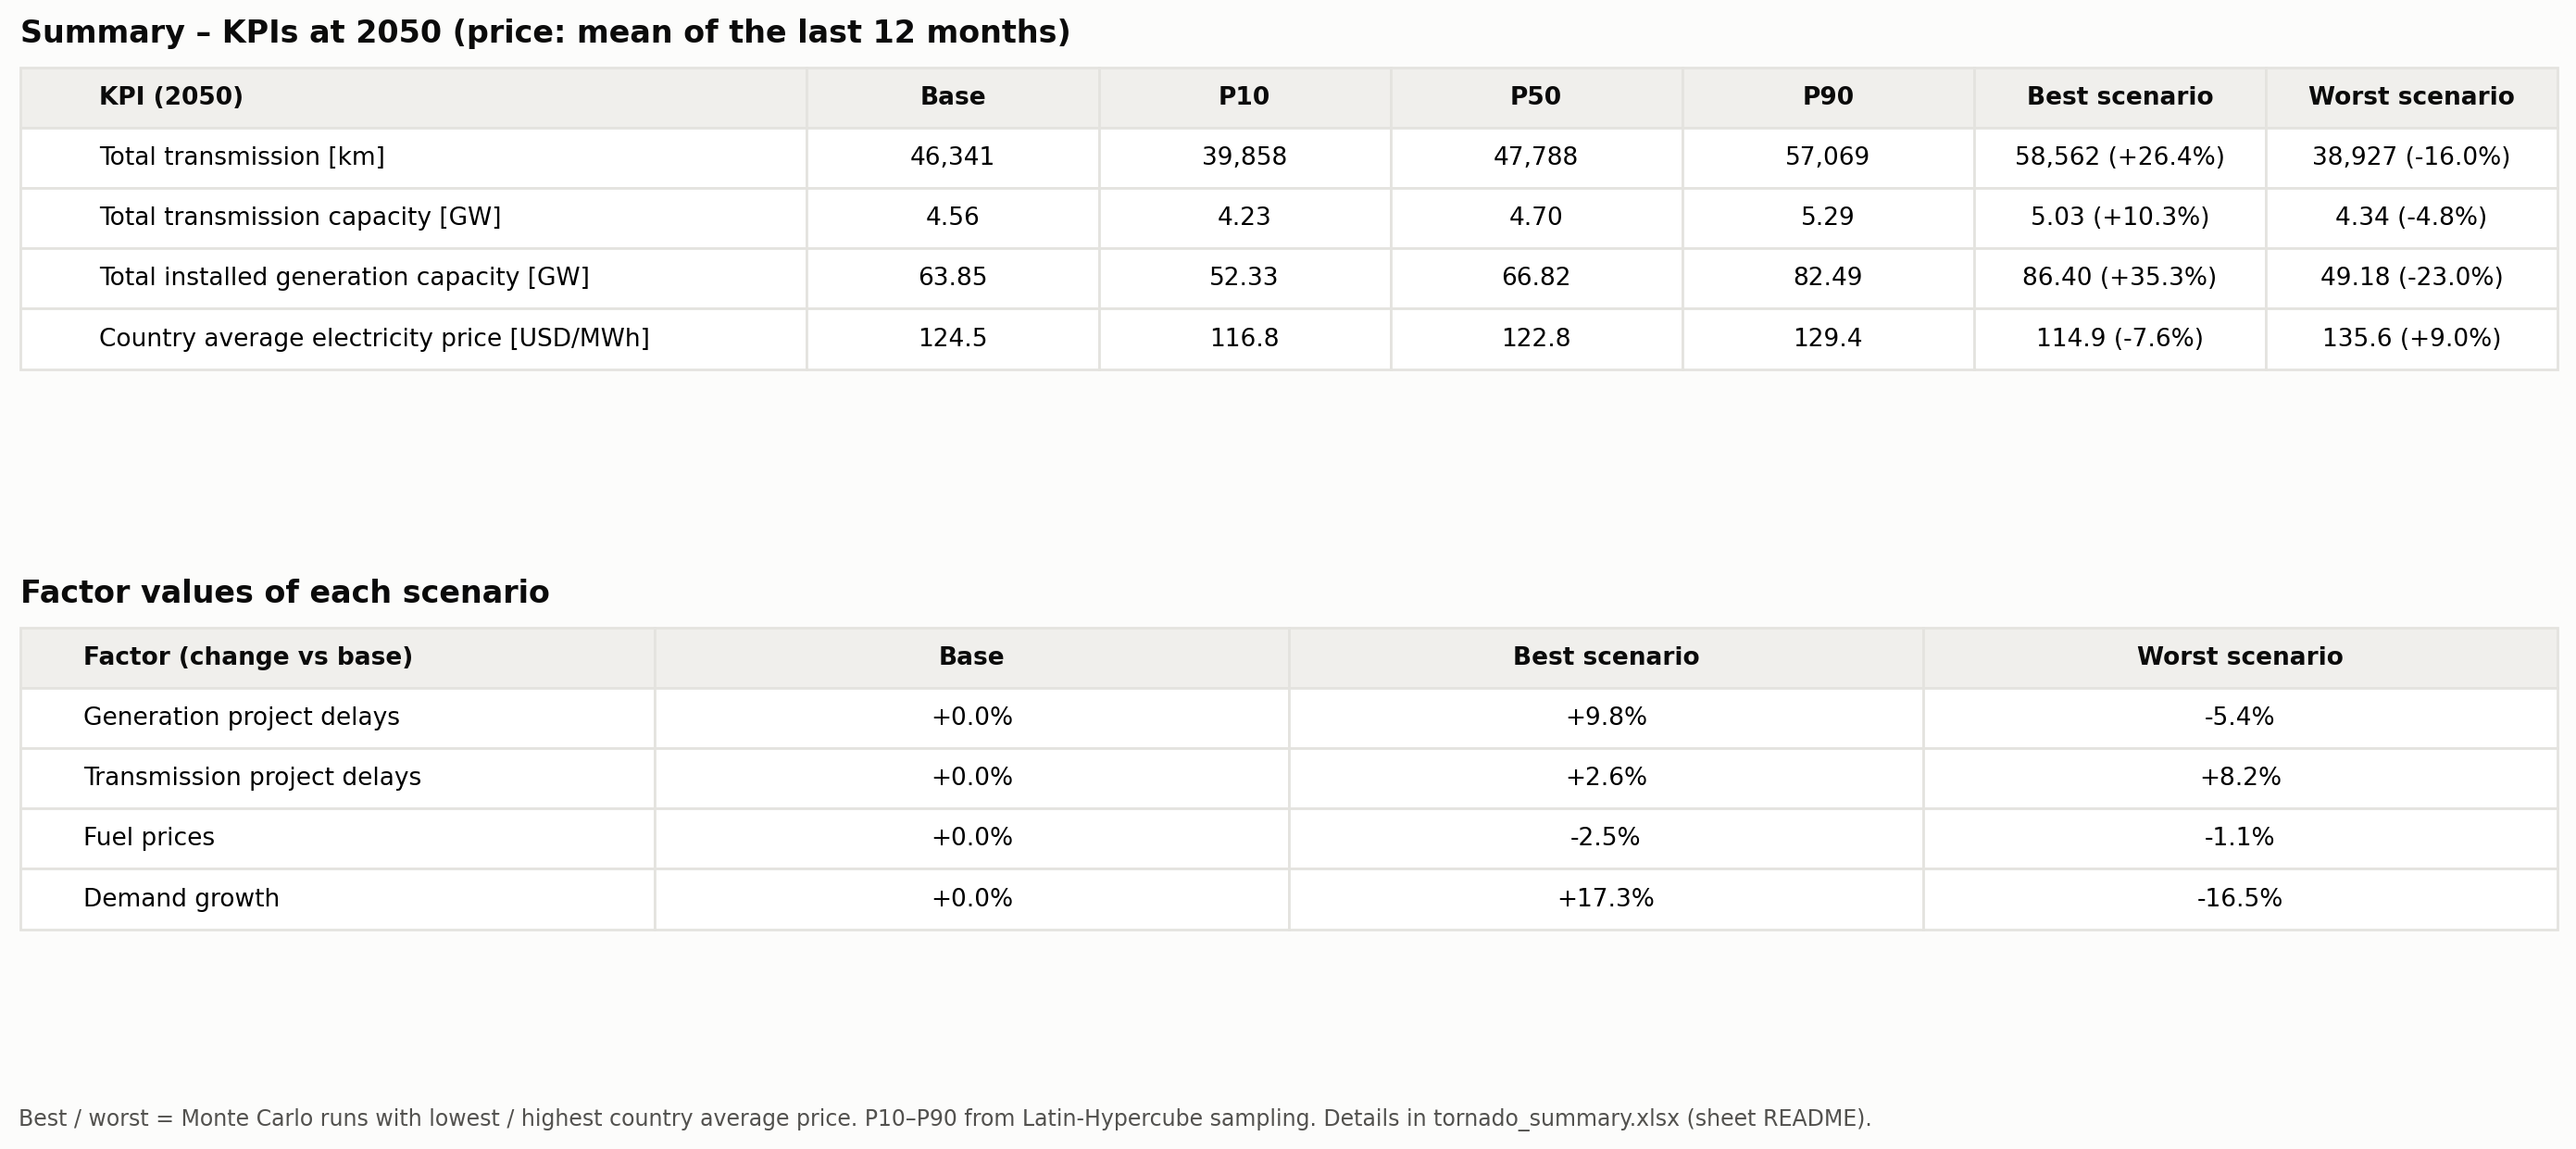

tornado_summary.xlsx sheets:
  README                     18 rows x  2 columns
  Best_Worst_Scenarios        3 rows x 22 columns
  Distribution_P10_P90        4 rows x  9 columns
  Tornado                    16 rows x 12 columns
  All_runs                  129 rows x 10 columns
  Convergence                28 rows x  6 columns
  Rank_correlation            4 rows x  5 columns


,KPI,Unit,Factor,Range,Base value,Value with factor low,Value with factor high,Change (low),Change (high),Change (low) %,Change (high) %,Swing |high−low|
0,Country average electricity price,USD/MWh,Demand growth,−20% / +20%,124.463,131.308,118.222,6.845,-6.241,5.500,-5.014,13.086
1,Country average electricity price,USD/MWh,Generation project delays,−20% / +20%,124.463,118.600,124.122,-5.863,-0.340,-4.711,-0.273,5.523
2,Country average electricity price,USD/MWh,Transmission project delays,−20% / +20%,124.463,123.102,125.729,-1.360,1.266,-1.093,1.017,2.626
3,Country average electricity price,USD/MWh,Fuel prices,−15% / +15%,124.463,124.960,124.954,0.497,0.492,0.399,0.395,0.005
4,Total installed generation capacity,GW,Demand growth,−20% / +20%,63.850,48.499,82.578,-15.351,18.728,-24.042,29.332,34.079
5,Total installed generation capacity,GW,Generation project delays,−20% / +20%,63.850,70.638,64.553,6.788,0.704,10.631,1.102,6.085
6,Total installed generation capacity,GW,Fuel prices,−15% / +15%,63.850,64.078,64.718,0.229,0.868,0.358,1.360,0.640
7,Total installed generation capacity,GW,Transmission project delays,−20% / +20%,63.850,64.720,64.643,0.870,0.794,1.363,1.243,0.076
8,Total transmission,km,Demand growth,−20% / +20%,46341.234,37589.227,57383.387,-8752.008,11042.152,-18.886,23.828,19794.160
9,Total transmission,km,Generation project delays,−20% / +20%,46341.234,49317.469,47107.207,2976.234,765.973,6.422,1.653,2210.262


In [19]:
display(Image(filename=str(FIGURES / "00_summary_table.png")))

tables = pd.read_excel(FIGURES / "tornado_summary.xlsx", sheet_name=None)
print("tornado_summary.xlsx sheets:")
for name, frame in tables.items():
    print(f"  {name:24s} {frame.shape[0]:4d} rows x {frame.shape[1]:2d} columns")
display(tables["Tornado"].head(12))

## 10. Reproducibility checks

Assertions rather than prose, so that re-executing the notebook *fails* if any of these
stops holding.

In [20]:
# 1. The design is reproducible from the seeds in the source alone.
again = pt.design_runs()
assert again.equals(design), "design_runs() is not deterministic"
print("1. design reproducible from the fixed seeds                      OK")

# 2. Every completed run carries exactly the factor values the design assigns it.
mismatched = [rid for rid in data
              if not pt._matches_design(RUNS, rid, pt._params(design.loc[rid]))]
assert not mismatched, f"runs whose factors do not match the design: {mismatched}"
print("2. every loaded run matches its design row                       OK")

# 3. The tornado runs actually moved the model: each must differ from the base case.
flat = [f"oat_{key}_{side}" for key in pt.FACTORS for side in ("low", "high")
        if f"oat_{key}_{side}" in kpi.index
        and (kpi.loc[f"oat_{key}_{side}"] - base).abs().max() < 1e-9]
assert not flat, f"tornado runs identical to the base case: {flat}"
print("3. every tornado run differs from the base case                  OK")

# 4. The first Monte Carlo block still reproduces the earlier 120-sample design, which is
#    what makes reusing its completed runs legitimate.
first_block = pt.design_runs(blocks=[pt.MC_BLOCKS[0]])
shared = [r for r in first_block.index if r.startswith("mc_")]
assert np.allclose(first_block.loc[shared, list(pt.FACTORS)].astype(float).to_numpy(),
                   design.loc[shared, list(pt.FACTORS)].astype(float).to_numpy())
print("4. block 1 is unchanged, so its completed runs are reusable      OK")

1. design reproducible from the fixed seeds                      OK


2. every loaded run matches its design row                       OK
3. every tornado run differs from the base case                  OK
4. block 1 is unchanged, so its completed runs are reusable      OK


---

### Where each result goes

| Product | File | Used for |
|---|---|---|
| Tornado | `figures/03_tornado.png` | which unknown matters, and in which direction |
| P10–P90 over time | `figures/01_distribution_P10_P90_timeseries.png` | how wide the future stays |
| P10–P90 in 2050 | `figures/02_distribution_P10_P90_histograms.png` | the outcome distribution |
| Price, best / base / worst | `figures/04_price_best_worst.png` | what the extremes cost |
| Installed capacity by technology | `figures/05_installed_capacity_by_technology.png` | best vs. worst mix |
| Generation by technology | `figures/06_generation_by_technology.png` | best vs. worst mix |
| Transmission | `figures/07_…GW.png`, `08_…km.png` | the grid each path requires |
| Method checks | `figures/09`, `10`, `11` | sampling, convergence, factor influence |
| All numbers | `figures/tornado_summary.xlsx` | every value behind every claim |

The limitations that bound all of this are in `README.md` section 8 — in particular that the
ranges are ranges of admissibility rather than estimated distributions, that the factors are
treated as independent, and that everything not listed as a factor is held at its
`PERU.xlsx` value.